# Importing the relevant libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectPercentile, f_classif, VarianceThreshold
import joblib


# Loading the dataset

In [ ]:
df = pd.read_csv('/content/parkinsons (1).csv')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## Understanding and examining the structure and organization of dataset

In [ ]:
df.shape

(195, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

## Eliminating the unnecessary columns

In [ ]:
df.drop('name',axis=1,inplace=True)

In [ ]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
df.isnull().sum()

,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0
MDVP:Shimmer(dB),0


In [ ]:
df[df.duplicated()]

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE


<Axes: ylabel='count'>

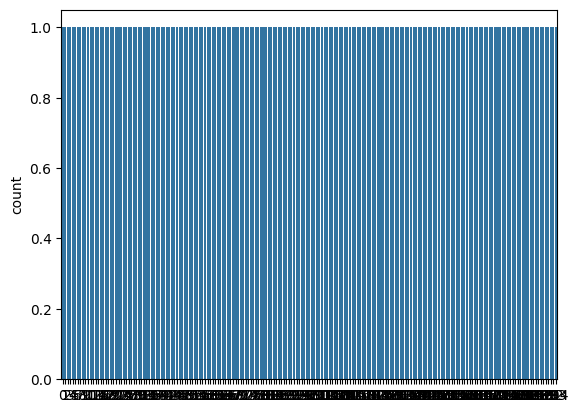

In [ ]:
sns.countplot(df['status'])

The target label 'status' is highly imbalanced so we need to balance it out.

<Axes: >

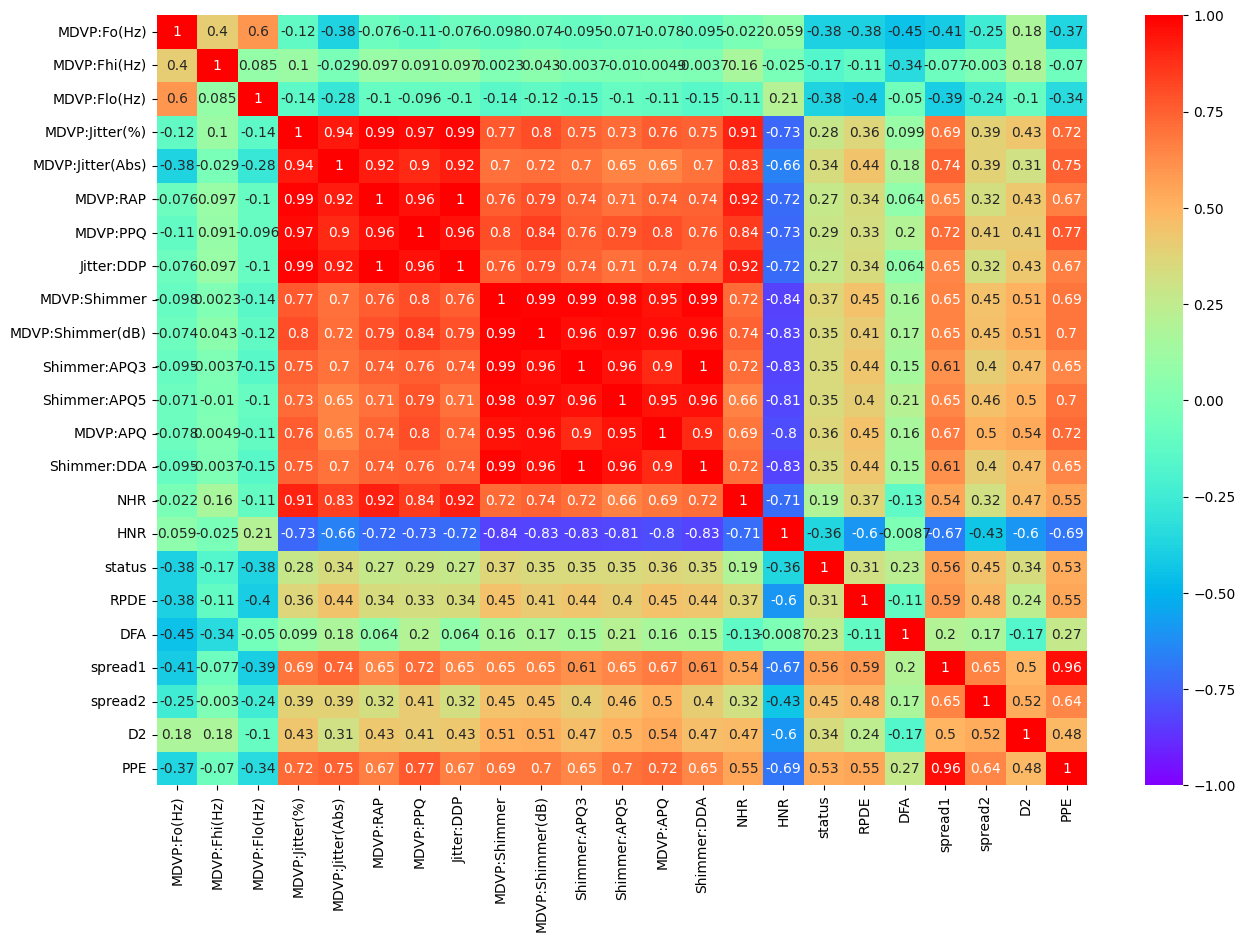

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,vmin=-1,vmax=1,cmap='rainbow')

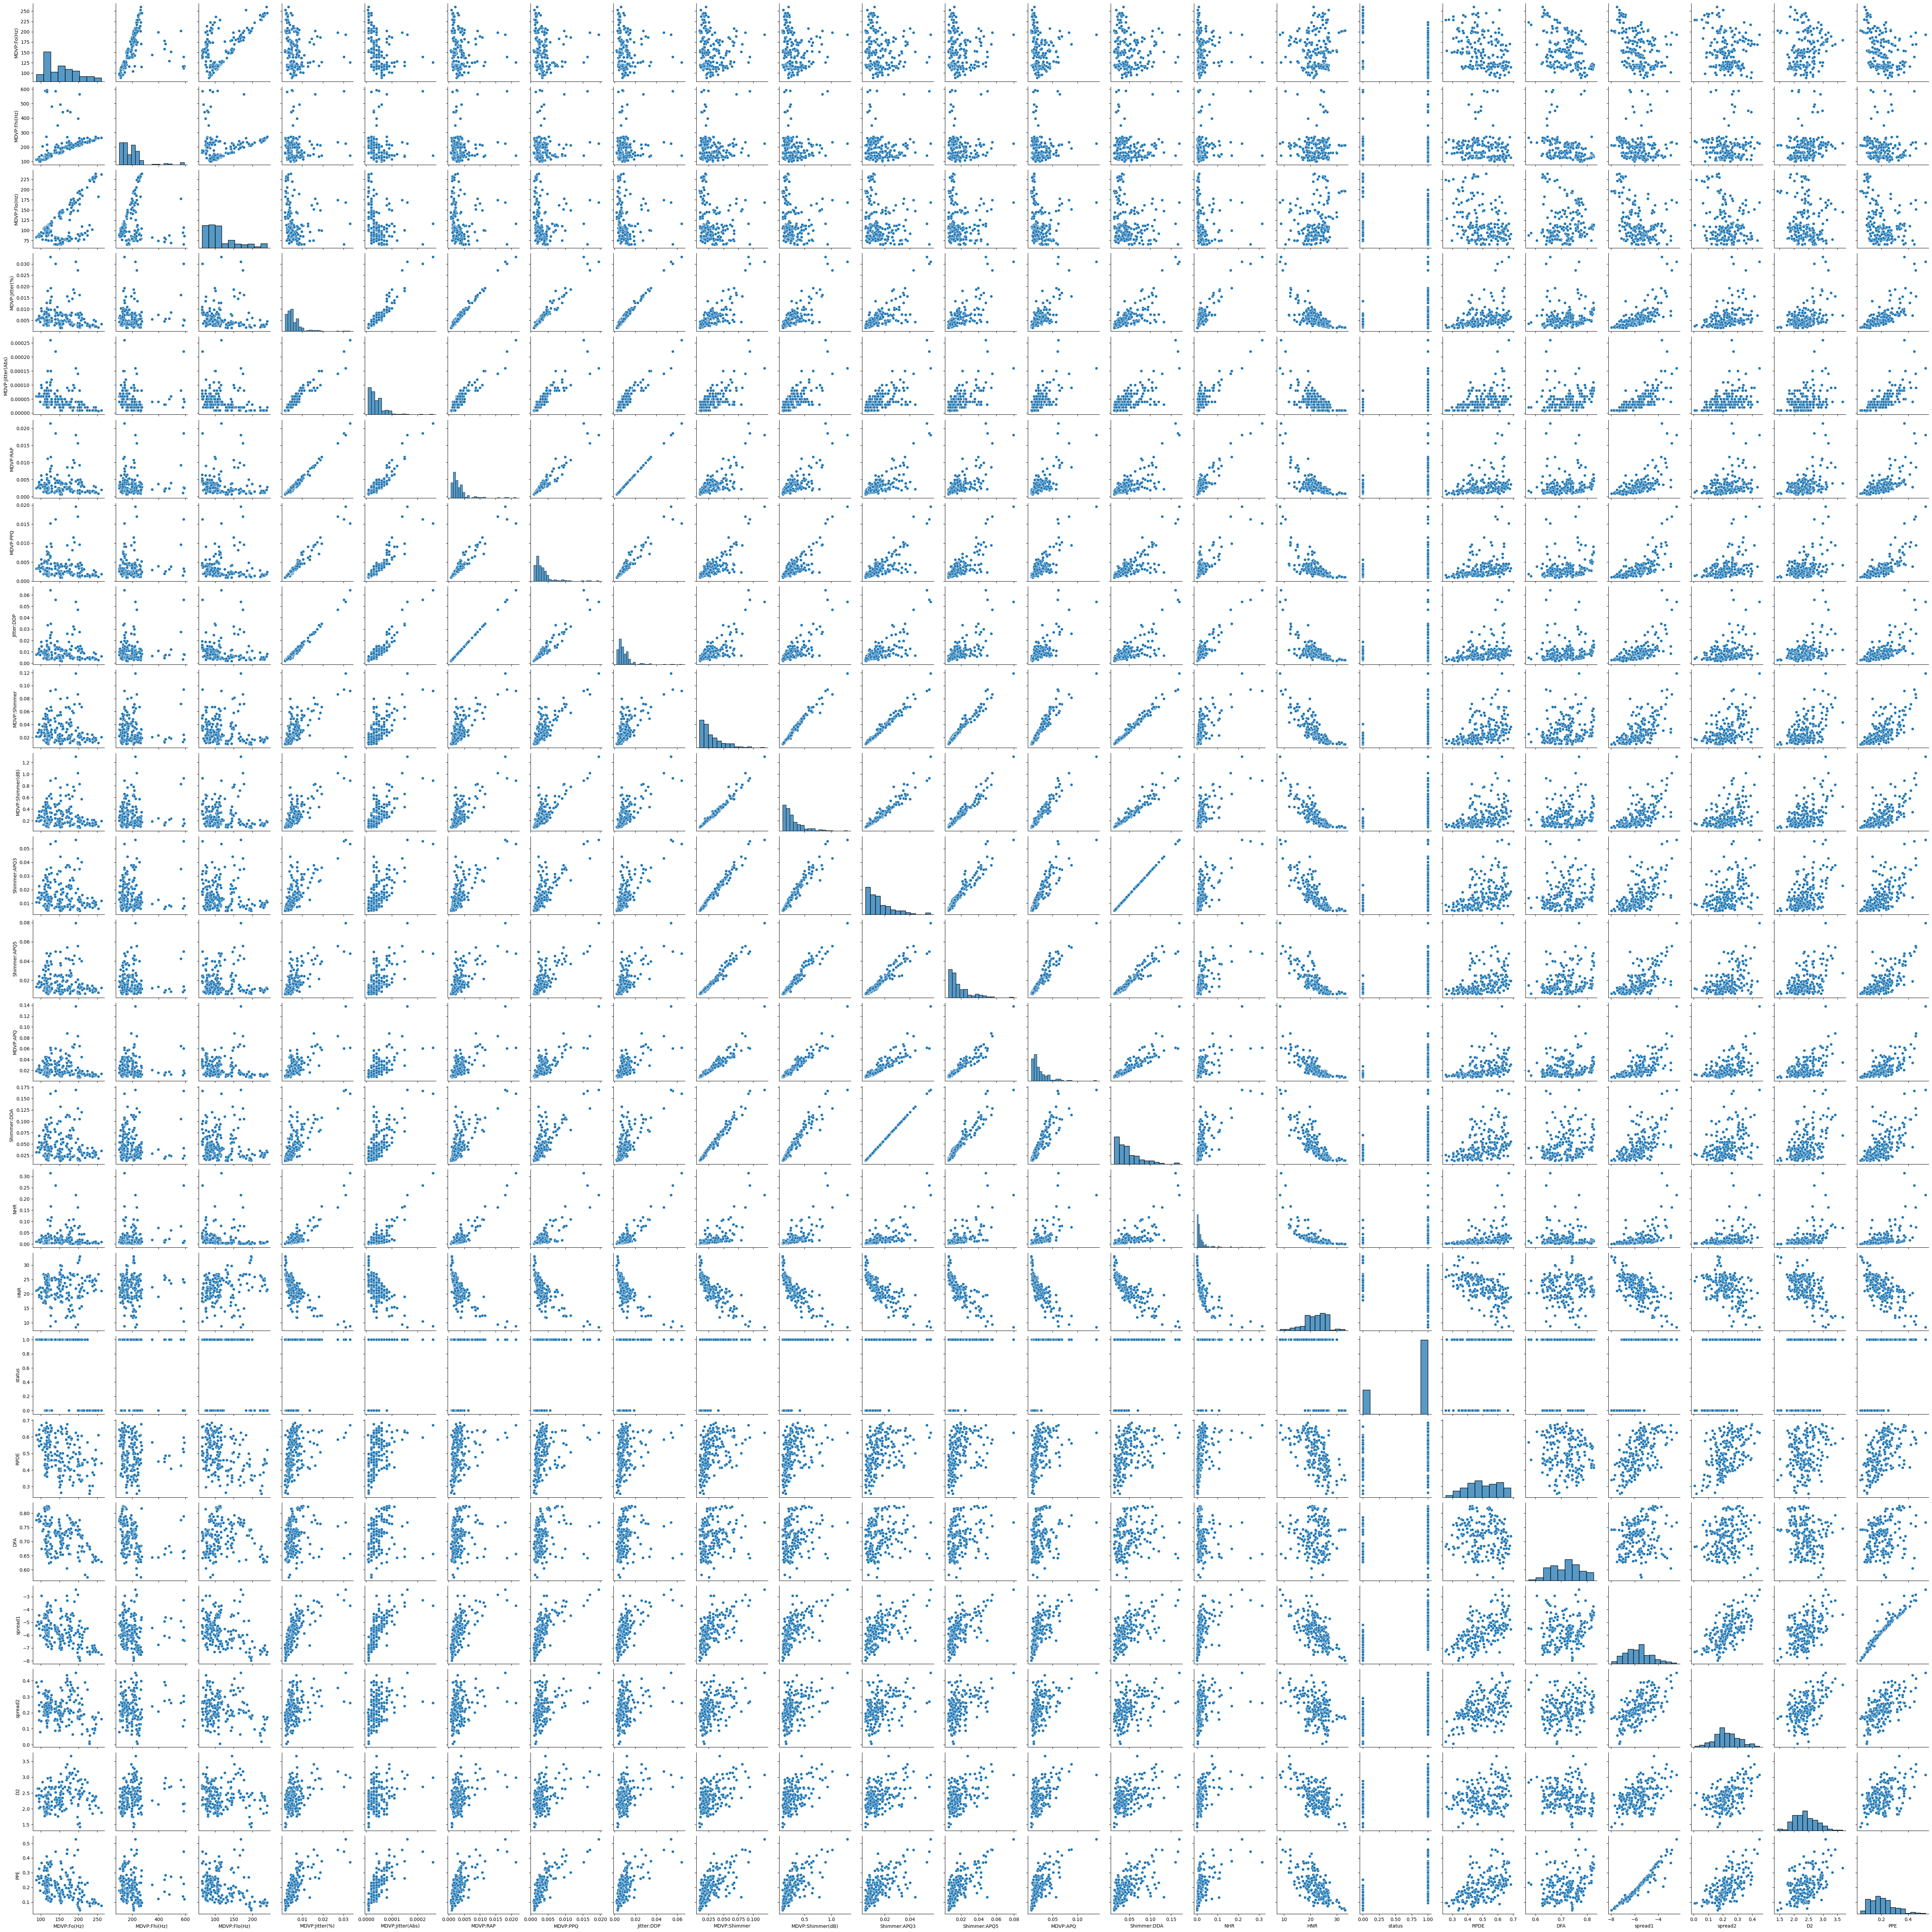

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



sns.pairplot(df)
plt.show()


# Resampling the dataset using Synthetic Minority Oversampling Technique(SMOTE)

In [ ]:
X = df.drop('status',axis=1)
y = df['status']

In [ ]:
sm = SMOTE(k_neighbors=10)
X,y = sm.fit_resample(X,y)

<Axes: ylabel='count'>

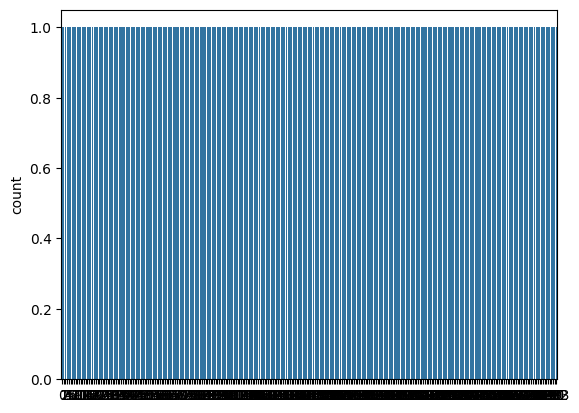

In [ ]:
sns.countplot(y)

# Feature Selection

Let's look for constant features

In [ ]:
sel = VarianceThreshold(threshold=0)
sel.fit(X,y)

VarianceThreshold(threshold=0)

In [ ]:
sum(sel.get_support())

np.int64(22)

In [ ]:
# Printing the total number of constant features
print(len([x for x in X.columns if x not in X.columns[sel.get_support()]]))
[x for x in X.columns if x not in X.columns[sel.get_support()]]

0


[]

There are no features with constant variance.

### Selecting the features in the top 20 percentile

In [ ]:
percentile = SelectPercentile(f_classif,percentile=20)
percentile.fit(X,y)

SelectPercentile(percentile=20)

Text(0.5, 1.0, 'Feature Importances')

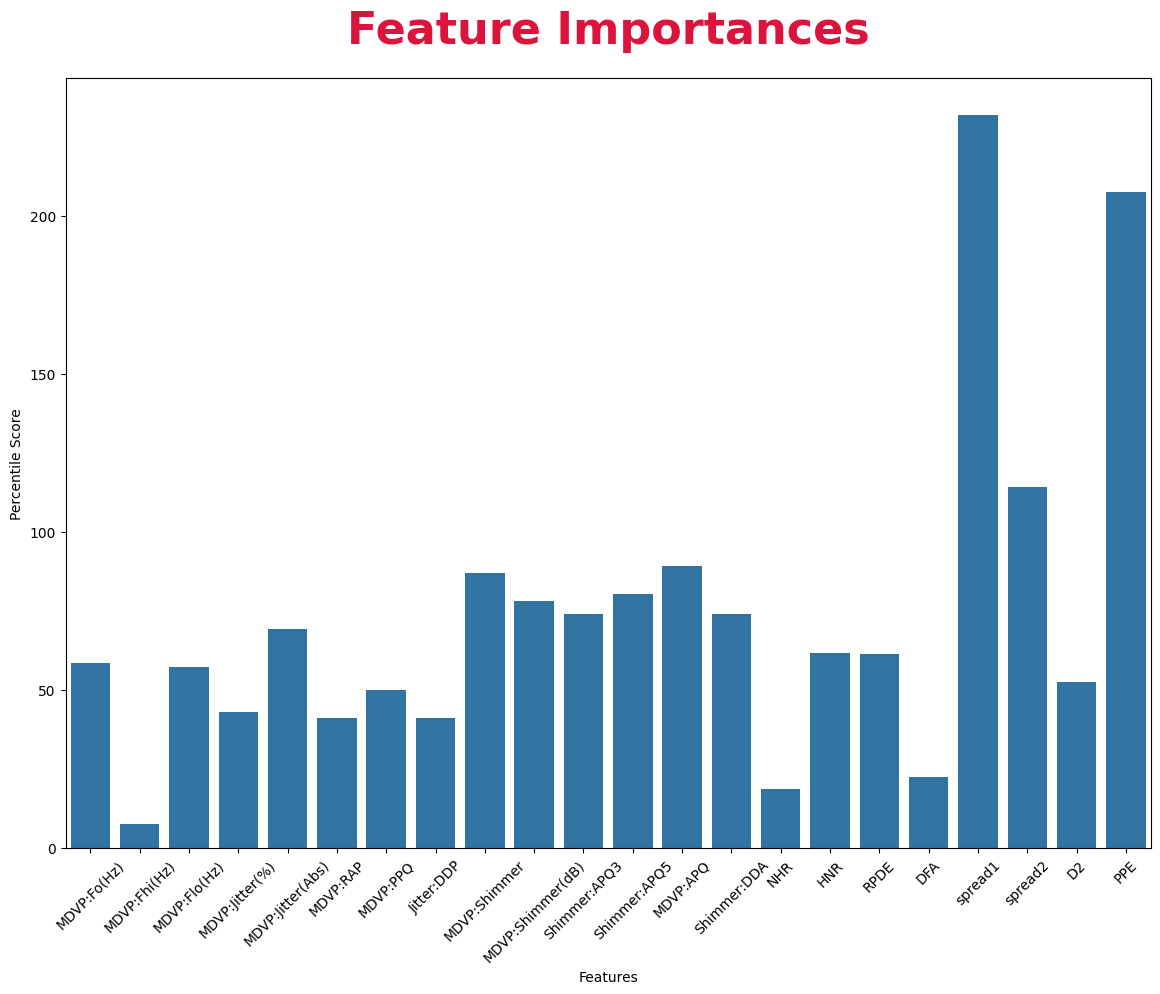

In [ ]:
plt.figure(figsize=(14,10))
sns.barplot(x=X.columns, y=percentile.scores_)
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Percentile Score')
plt.title('Feature Importances',fontsize=32,color='crimson',fontweight='bold',pad=25)

'Spread1' and 'PPE' are the most important predictor variables in the entire dataset.

In [ ]:
sum(percentile.get_support())

np.int64(5)

In [ ]:
X.columns[percentile.get_support()]

Index(['MDVP:Shimmer', 'MDVP:APQ', 'spread1', 'spread2', 'PPE'], dtype='object')

In [ ]:
X = percentile.transform(X)

# Dividing the dataset into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=1234)

# Model Training and Evaluation

In [ ]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [ ]:
lr_pred = lr.predict(X_test)
lr_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,lr_pred))
print(classification_report(y_test,lr_pred))

[[50  6]
 [14 48]]
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        56
           1       0.89      0.77      0.83        62

    accuracy                           0.83       118
   macro avg       0.84      0.83      0.83       118
weighted avg       0.84      0.83      0.83       118



In [ ]:
nbr_range = np.arange(1,21)
accuracy_scores = []
for i in nbr_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    knn_pred = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test,knn_pred))

<Axes: >

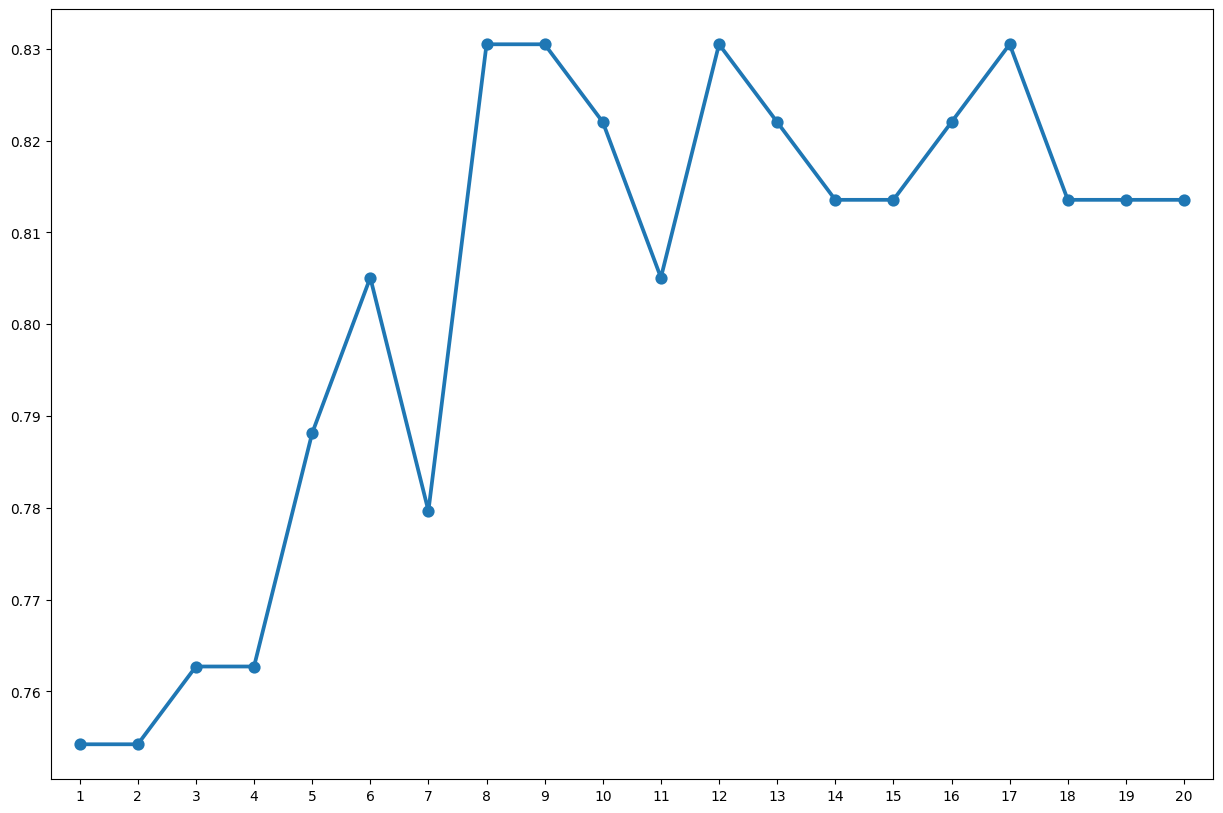

In [ ]:
plt.figure(figsize=(15,10))
sns.pointplot(x=nbr_range,y=accuracy_scores)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = knn.predict(X_test)
knn_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,knn_pred))
print(classification_report(y_test,knn_pred))

[[45 11]
 [14 48]]
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        56
           1       0.81      0.77      0.79        62

    accuracy                           0.79       118
   macro avg       0.79      0.79      0.79       118
weighted avg       0.79      0.79      0.79       118



In [ ]:
svm = SVC(random_state=1234)
svm.fit(X_train,y_train)

SVC(random_state=1234)

In [ ]:
svm_pred = svm.predict(X_test)
svm_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,svm_pred))
print(classification_report(y_test,svm_pred))

[[50  6]
 [15 47]]
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        56
           1       0.89      0.76      0.82        62

    accuracy                           0.82       118
   macro avg       0.83      0.83      0.82       118
weighted avg       0.83      0.82      0.82       118



In [ ]:
dtree = DecisionTreeClassifier(random_state=1234)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1234)

In [ ]:
dtree_pred = dtree.predict(X_test)
dtree_pred

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,dtree_pred))
print(classification_report(y_test,dtree_pred))

[[50  6]
 [ 9 53]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        56
           1       0.90      0.85      0.88        62

    accuracy                           0.87       118
   macro avg       0.87      0.87      0.87       118
weighted avg       0.87      0.87      0.87       118



In [ ]:
no_of_estimators = np.arange(100,1100,100)
accuracy_scores = []

for i in no_of_estimators:
    rfc = RandomForestClassifier(n_estimators=i,random_state=1234)
    rfc.fit(X_train,y_train)
    rfc_pred = rfc.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test,rfc_pred))

In [ ]:
# plt.figure(figsize=(15,10))
# # sns.pointplot(no_of_estimators,accuracy_scores,color='indigo')
# sns.pointplot(x=no_of_estimators, y=accuracy_scores, color='indigo')
# plt.xlabel('No. of estimators',labelpad=20)
# plt.ylabel('Accuracy Score',labelpad=20)
# plt.title('Variation of accuracy scores according to no. of estimators',fontsize=32,color='sienna',fontweight='bold',pad=25)

In [ ]:
rfc = RandomForestClassifier(n_estimators=200,random_state=1234)
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=1234)

In [ ]:
rfc_pred = rfc.predict(X_test)
rfc_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1])

In [ ]:
print(confusion_matrix(y_test,rfc_pred))
print(classification_report(y_test,rfc_pred))

[[51  5]
 [ 9 53]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        56
           1       0.91      0.85      0.88        62

    accuracy                           0.88       118
   macro avg       0.88      0.88      0.88       118
weighted avg       0.88      0.88      0.88       118



In [ ]:
xgb = XGBClassifier(random_state=1234)
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_pred

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))

[[50  6]
 [ 9 53]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        56
           1       0.90      0.85      0.88        62

    accuracy                           0.87       118
   macro avg       0.87      0.87      0.87       118
weighted avg       0.87      0.87      0.87       118



In [ ]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [ ]:
gnb_pred = gnb.predict(X_test)
gnb_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1])

In [ ]:
print(confusion_matrix(y_test,gnb_pred))
print(classification_report(y_test,gnb_pred))

[[56  0]
 [16 46]]
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        56
           1       1.00      0.74      0.85        62

    accuracy                           0.86       118
   macro avg       0.89      0.87      0.86       118
weighted avg       0.89      0.86      0.86       118



In [ ]:
param_grid = {'C': [1,10,100,1000,10000], 'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel': ['rbf']}

In [ ]:
grid_search = GridSearchCV(SVC(),param_grid,refit=True,verbose=4)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.944 total time=   0.0s
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.886 total time=   0.0s
[CV 3/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.743 total time=   0.0s
[CV 4/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.743 total time=   0.0s
[CV 5/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 1/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.917 total time=   0.0s
[CV 2/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.857 total time=   0.0s
[CV 3/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.743 total time=   0.0s
[CV 4/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.686 total time=   0.0s
[CV 5/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.771 total time=   0.0s
[CV 1/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.889 total time=   0.0s
[CV 2/5] END .......C=1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100, 1000, 10000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=4)

In [ ]:
grid_search.best_estimator_

SVC(C=10000, gamma=1)

In [ ]:
grid_search.best_score_

np.float64(0.8688888888888888)

In [ ]:
optimised_svm_pred = grid_search.predict(X_test)
optimised_svm_pred

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0])

In [ ]:
print(confusion_matrix(y_test,optimised_svm_pred))
print(classification_report(y_test,optimised_svm_pred))

[[56  0]
 [13 49]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        56
           1       1.00      0.79      0.88        62

    accuracy                           0.89       118
   macro avg       0.91      0.90      0.89       118
weighted avg       0.91      0.89      0.89       118



In [ ]:
param_grid = {'criterion': ["gini", "entropy"],
              'splitter': ["best", "random"],
              'max_depth': [5,10,15,20,25],
              'max_features': ['auto','sqrt','log2']
             }

In [ ]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=1234),param_grid,refit=True,verbose=3)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END criterion=gini, max_depth=5, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=5, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=5, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=5, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=5, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=5, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=5, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=5, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=5, max_features=auto, splitter=random;, score

GridSearchCV(estimator=DecisionTreeClassifier(random_state=1234),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             verbose=3)

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=15, max_features='sqrt',
                       random_state=1234, splitter='random')

In [ ]:
grid_search.best_score_

np.float64(0.8806349206349207)

In [ ]:
optimised_dtree_pred = grid_search.predict(X_test)
optimised_dtree_pred

array([0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1])

In [ ]:
print(confusion_matrix(y_test,optimised_dtree_pred))
print(classification_report(y_test,optimised_dtree_pred))

[[36 20]
 [11 51]]
              precision    recall  f1-score   support

           0       0.77      0.64      0.70        56
           1       0.72      0.82      0.77        62

    accuracy                           0.74       118
   macro avg       0.74      0.73      0.73       118
weighted avg       0.74      0.74      0.73       118



In [ ]:
param_grid = {
    'n_estimators': [100,500,700,900],
    'criterion': ['gini','entropy'],
    'max_features': ['auto','sqrt','log2'],
    'oob_score': [True,False],
    'class_weight': ['balanced','balanced_subsample']}

In [ ]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=1234),param_grid,refit=True,verbose=4)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV 1/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=True;, score=nan total time=   0.0s
[CV 2/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=True;, score=nan total time=   0.0s
[CV 3/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=True;, score=nan total time=   0.0s
[CV 4/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=True;, score=nan total time=   0.0s
[CV 5/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=True;, score=nan total time=   0.0s
[CV 1/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=False;, score=nan total time=   0.0s
[CV 2/5] END class_weight=balanced, criterion=gini, max_features=auto, n_estimators=100, oob_score=False;, score=nan total time

GridSearchCV(estimator=RandomForestClassifier(random_state=1234),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy'],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [100, 500, 700, 900],
                         'oob_score': [True, False]},
             verbose=4)

In [ ]:
grid_search.best_score_

np.float64(0.8577777777777778)

In [ ]:
rfc = RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy', max_features='log2', n_estimators=500, oob_score=True, random_state=60)
rfc.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy',
                       max_features='log2', n_estimators=500, oob_score=True,
                       random_state=60)

In [ ]:
optimised_rfc_pred = rfc.predict(X_test)
optimised_rfc_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1])

In [ ]:
print(confusion_matrix(y_test,optimised_rfc_pred))
print(classification_report(y_test,optimised_rfc_pred))

[[50  6]
 [ 9 53]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        56
           1       0.90      0.85      0.88        62

    accuracy                           0.87       118
   macro avg       0.87      0.87      0.87       118
weighted avg       0.87      0.87      0.87       118



## Conclusion

In [ ]:
print("Performance of all ML models used:")
print("Accuracy Score of Logistic Regression:",str(np.round(accuracy_score(y_test,lr_pred)*100,2)) + '%')
print("Accuracy Score of K Neighbors Classifier:",str(np.round(accuracy_score(y_test,knn_pred)*100,2)) + '%')
print("Accuracy Score of Support Vector Classifier:",str(np.round(accuracy_score(y_test,optimised_svm_pred)*100,2)) + '%')
print("Accuracy Score of Decision Tree Classifier:",str(np.round(accuracy_score(y_test,optimised_dtree_pred)*100,2)) + '%')
print("Accuracy Score of Random Forest Classifier:",str(np.round(accuracy_score(y_test,optimised_rfc_pred)*100,2)) + '%')
print("Accuracy Score of Gaussian Naive Bayes:",str(np.round(accuracy_score(y_test,gnb_pred)*100,2)) + '%')
print("Accuracy Score of XG Boost Classifier:",str(np.round(accuracy_score(y_test,xgb_pred)*100,2)) + '%')

Performance of all ML models used:
Accuracy Score of Logistic Regression: 83.05%
Accuracy Score of K Neighbors Classifier: 78.81%
Accuracy Score of Support Vector Classifier: 88.98%
Accuracy Score of Decision Tree Classifier: 73.73%
Accuracy Score of Random Forest Classifier: 87.29%
Accuracy Score of Gaussian Naive Bayes: 86.44%
Accuracy Score of XG Boost Classifier: 87.29%


In [ ]:
lr_acc   = np.round(accuracy_score(y_test, lr_pred) * 100, 2)
knn_acc  = np.round(accuracy_score(y_test, knn_pred) * 100, 2)
svm_acc  = np.round(accuracy_score(y_test, optimised_svm_pred) * 100, 2)
dt_acc   = np.round(accuracy_score(y_test, optimised_dtree_pred) * 100, 2)
rf_acc   = np.round(accuracy_score(y_test, optimised_rfc_pred) * 100, 2)
gnb_acc  = np.round(accuracy_score(y_test, gnb_pred) * 100, 2)
xgb_acc  = np.round(accuracy_score(y_test, xgb_pred) * 100, 2)

### Random Forest Classifier predicted the Parkinson's disease to the highest accuracy level, even though, Logistic Regression had the worst performance among all models.

## Saving the model

In [ ]:
joblib.dump(rfc,'model.pkl')

['model.pkl']

In [ ]:
joblib.load('model.pkl')

RandomForestClassifier(class_weight='balanced_subsample', criterion='entropy',
                       max_features='log2', n_estimators=500, oob_score=True,
                       random_state=60)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features (X), Labels (y)
X = df.drop('status', axis=1).values
y = df['status'].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for CNN [samples, timesteps, features=1]
X = np.expand_dims(X, axis=2)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN Model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"CNN Accuracy: {acc:.4f}")


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 326ms/step - accuracy: 0.6112 - loss: 0.6333 - val_accuracy: 0.8205 - val_loss: 0.4777
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7536 - loss: 0.4681 - val_accuracy: 0.8462 - val_loss: 0.4093
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8143 - loss: 0.3861 - val_accuracy: 0.8205 - val_loss: 0.3830
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8453 - loss: 0.3892 - val_accuracy: 0.8205 - val_loss: 0.3568
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8576 - loss: 0.3196 - val_accuracy: 0.8205 - val_loss: 0.3495
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8066 - loss: 0.3507 - val_accuracy: 0.8205 - val_loss: 0.3295
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8682 - loss: 0.2903 - val_accuracy: 0.7949 - val_loss: 0.3271
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8200 - loss: 0.3384 - val_accuracy: 0.8462 - val_lo

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 35.8 MB/s eta 0:00:00


TRAINING OF CNN

In [ ]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_cnn(trial):
    model = Sequential()

    # Conv Layer 1
    model.add(Conv1D(
        filters=trial.suggest_categorical('filters_1', [32, 64, 128]),
        kernel_size=trial.suggest_categorical('kernel_size_1', [3, 5]),
        activation='relu',
        input_shape=(X.shape[1], 1)
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(trial.suggest_float('dropout_1', 0.2, 0.5)))

    # Conv Layer 2
    model.add(Conv1D(
        filters=trial.suggest_categorical('filters_2', [64, 128, 256]),
        kernel_size=trial.suggest_categorical('kernel_size_2', [3, 5]),
        activation='relu'
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(trial.suggest_float('dropout_2', 0.2, 0.5)))

    # Dense Layers
    model.add(Flatten())
    model.add(Dense(trial.suggest_categorical('dense_units', [32, 64, 128]), activation='relu'))
    model.add(Dropout(trial.suggest_float('dropout_3', 0.2, 0.5)))
    model.add(Dense(1, activation='sigmoid'))

    # Compile
    lr = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

    return model

def objective(trial):
    model = create_cnn(trial)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
        verbose=0
    )
    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print('Best trial:', study.best_trial.params)





[I 2025-12-22 14:37:18,631] A new study created in memory with name: no-name-c0756924-5d60-48e6-8aa9-8306e79cf70d
[I 2025-12-22 14:37:45,344] Trial 0 finished with value: 0.8205128312110901 and parameters: {'filters_1': 128, 'kernel_size_1': 3, 'dropout_1': 0.34316319562452885, 'filters_2': 64, 'kernel_size_2': 3, 'dropout_2': 0.42483210836953494, 'dense_units': 128, 'dropout_3': 0.22858817167388265, 'learning_rate': 0.00040761789890870825, 'batch_size': 32}. Best is trial 0 with value: 0.8205128312110901.
[I 2025-12-22 14:37:56,089] Trial 1 finished with value: 0.8205128312110901 and parameters: {'filters_1': 64, 'kernel_size_1': 3, 'dropout_1': 0.35893974467466705, 'filters_2': 256, 'kernel_size_2': 5, 'dropout_2': 0.207611720088214, 'dense_units': 64, 'dropout_3': 0.24549463837512492, 'learning_rate': 0.00013940112422446369, 'batch_size': 32}. Best is trial 0 with value: 0.8205128312110901.
[I 2025-12-22 14:38:06,812] Trial 2 finished with value: 0.9230769276618958 and parameters: {

Best trial: {'filters_1': 64, 'kernel_size_1': 3, 'dropout_1': 0.2794793550436814, 'filters_2': 256, 'kernel_size_2': 5, 'dropout_2': 0.270688969440397, 'dense_units': 64, 'dropout_3': 0.40536875497133196, 'learning_rate': 0.002197937478428617, 'batch_size': 64}


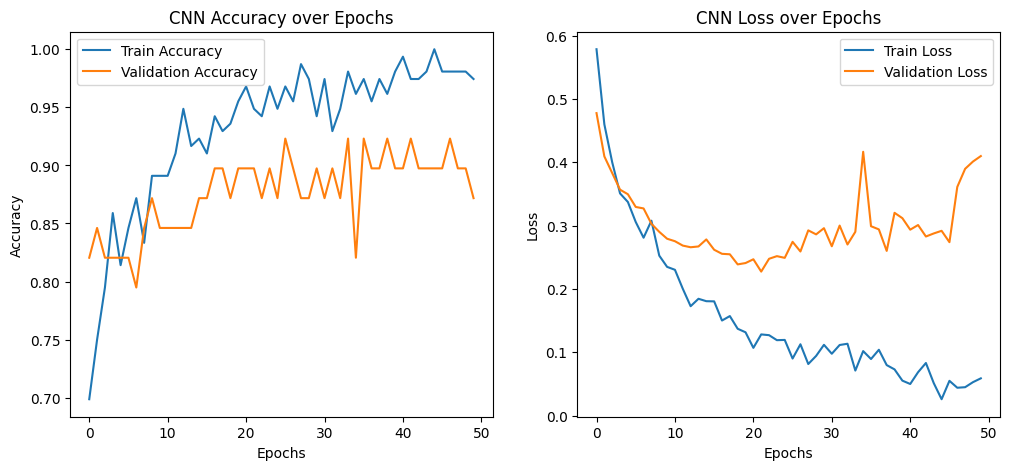

In [ ]:
import matplotlib.pyplot as plt

# Training history plot (for baseline CNN)
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Performance of all ML models used:
Logistic Regression: 83.05 %
K Neighbors Classifier: 78.81 %
Support Vector Classifier: 88.98 %
Decision Tree Classifier: 73.73 %
Random Forest Classifier: 87.29 %
Gaussian Naive Bayes: 86.44 %
XG Boost Classifier: 87.29 %
Convolutional Neural Network: 87.18 %


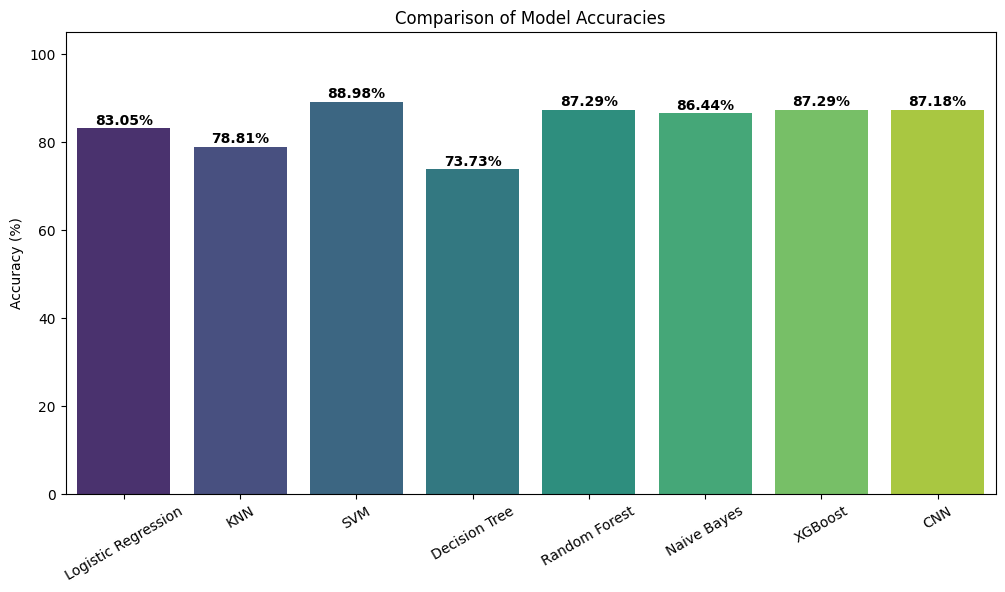

In [ ]:

# CNN accuracy from evaluation
cnn_acc  = np.round(acc * 100, 2)   # 'acc' comes from model.evaluate

print("Performance of all ML models used:")
print("Logistic Regression:", lr_acc, "%")
print("K Neighbors Classifier:", knn_acc, "%")
print("Support Vector Classifier:", svm_acc, "%")
print("Decision Tree Classifier:", dt_acc, "%")
print("Random Forest Classifier:", rf_acc, "%")
print("Gaussian Naive Bayes:", gnb_acc, "%")
print("XG Boost Classifier:", xgb_acc, "%")
print("Convolutional Neural Network:", cnn_acc, "%")

# Prepare data for plotting
models = ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest",
          "Naive Bayes", "XGBoost", "CNN"]

accuracies = [lr_acc, knn_acc, svm_acc, dt_acc, rf_acc, gnb_acc, xgb_acc, cnn_acc]

# Plot comparison
plt.figure(figsize=(12,6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=30)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.show()

In [ ]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling1D(),   # replaces Flatten()

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history2 = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))
loss2, acc2 = model.evaluate(X_test, y_test)
print(f"Improved CNN Accuracy: {acc2:.4f}")


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 623ms/step - accuracy: 0.7325 - loss: 0.5581 - val_accuracy: 0.8205 - val_loss: 0.6462
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7049 - loss: 0.4862 - val_accuracy: 0.8205 - val_loss: 0.5928
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8238 - loss: 0.3153 - val_accuracy: 0.8205 - val_loss: 0.5549
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8518 - loss: 0.3041 - val_accuracy: 0.8205 - val_loss: 0.5375
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8895 - loss: 0.3536 - val_accuracy: 0.8205 - val_loss: 0.5342
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8529 - loss: 0.2498 - val_accuracy: 0.8205 - val_loss: 0.5055
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8822 - loss: 0.2413 - val_accuracy: 0.8205 - val_loss: 0.5120
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8893 - loss: 0.2192 - val_accuracy: 0.8205 - val_l

In [ ]:
improved_cnn_acc = np.round(acc2 * 100, 2)
models.append("Improved CNN")
accuracies.append(improved_cnn_acc)


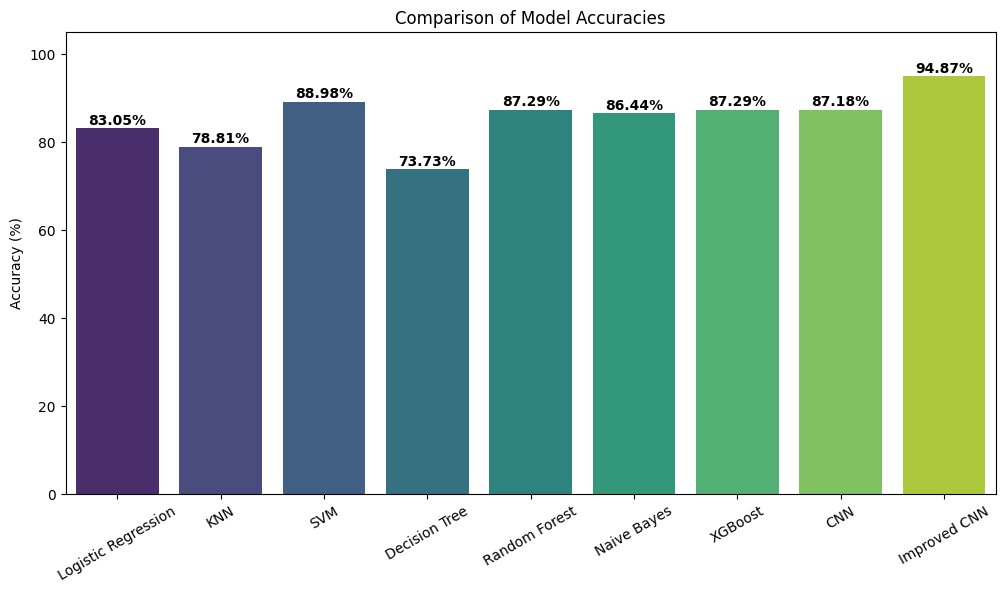

In [ ]:
# Plot comparison
plt.figure(figsize=(12,6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=30)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D

# make sure X_train exists and is reshaped
# If your features are 2D (e.g., (n_samples, height, width)), reshape them:
# X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
# X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))

# Build CNN model with 3 convolutional layers
model = Sequential()

# 1st Convolutional Layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))


# 2nd Convolutional Layer
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# ✅ 3rd Convolutional Layer (new)
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(GlobalAveragePooling1D())   # replaces Flatten()

# Fully Connected Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))   # prevents overfitting
model.add(Dense(1, activation='sigmoid'))  # binary classification

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_45 (Conv1D)              │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_44 (MaxPooling1D) │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 8, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_45 (MaxPooling1D) │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,825 (554.00 KB)

 Trainable params: 140,929 (550.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history2 = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))
loss2, acc2 = model.evaluate(X_test, y_test)
print(f"Improved CNN Accuracy: {acc2:.4f}")

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 456ms/step - accuracy: 0.5512 - loss: 0.9054 - val_accuracy: 0.8718 - val_loss: 0.6570
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7775 - loss: 0.4204 - val_accuracy: 0.8205 - val_loss: 0.5823
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8092 - loss: 0.3418 - val_accuracy: 0.8205 - val_loss: 0.5432
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8160 - loss: 0.3303 - val_accuracy: 0.8205 - val_loss: 0.4850
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8819 - loss: 0.2814 - val_accuracy: 0.8205 - val_loss: 0.4426
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8644 - loss: 0.3332 - val_accuracy: 0.8205 - val_loss: 0.4603
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8605 - loss: 0.2693 - val_accuracy: 0.8205 - val_loss: 0.4770
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9214 - loss: 0.2266 - val_accuracy: 0.8205 - val_lo

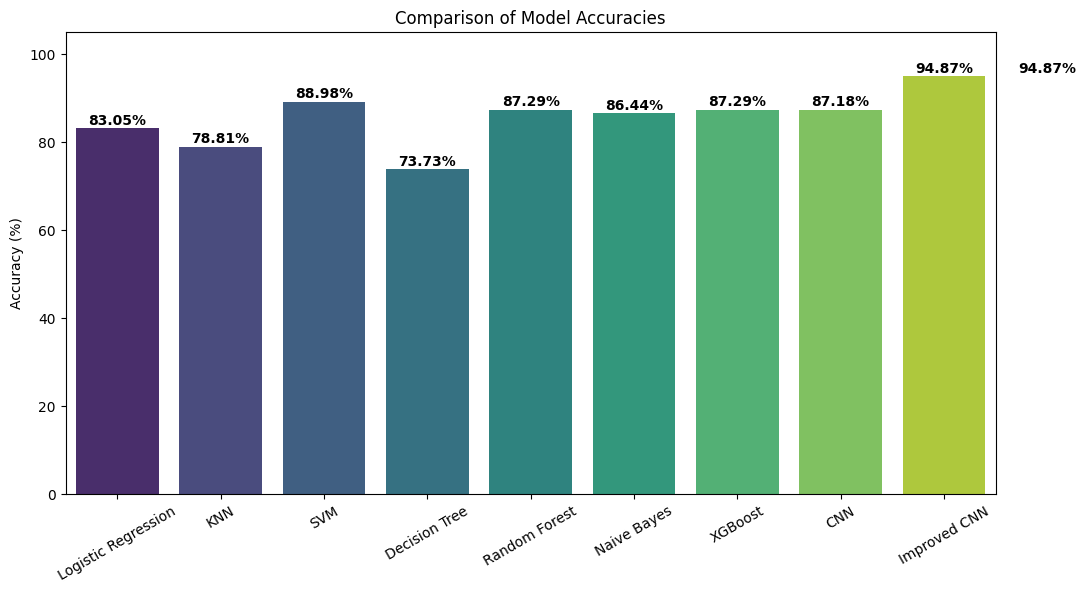

In [ ]:
improved_cnn_acc = np.round(acc2 * 100, 2)
models.append("Improved CNN")
accuracies.append(improved_cnn_acc)

# Plot comparison
plt.figure(figsize=(12,6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=30)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.show()

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[CV 1/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8;, score=0.906 total time=   0.0s
[CV 2/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8;, score=0.806 total time=   0.1s
[CV 3/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8;, score=0.903 total time=   0.0s
[CV 4/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8;, score=0.871 total time=   0.0s
[CV 5/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8;, score=0.742 total time=   0.0s
[CV 1/5] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1

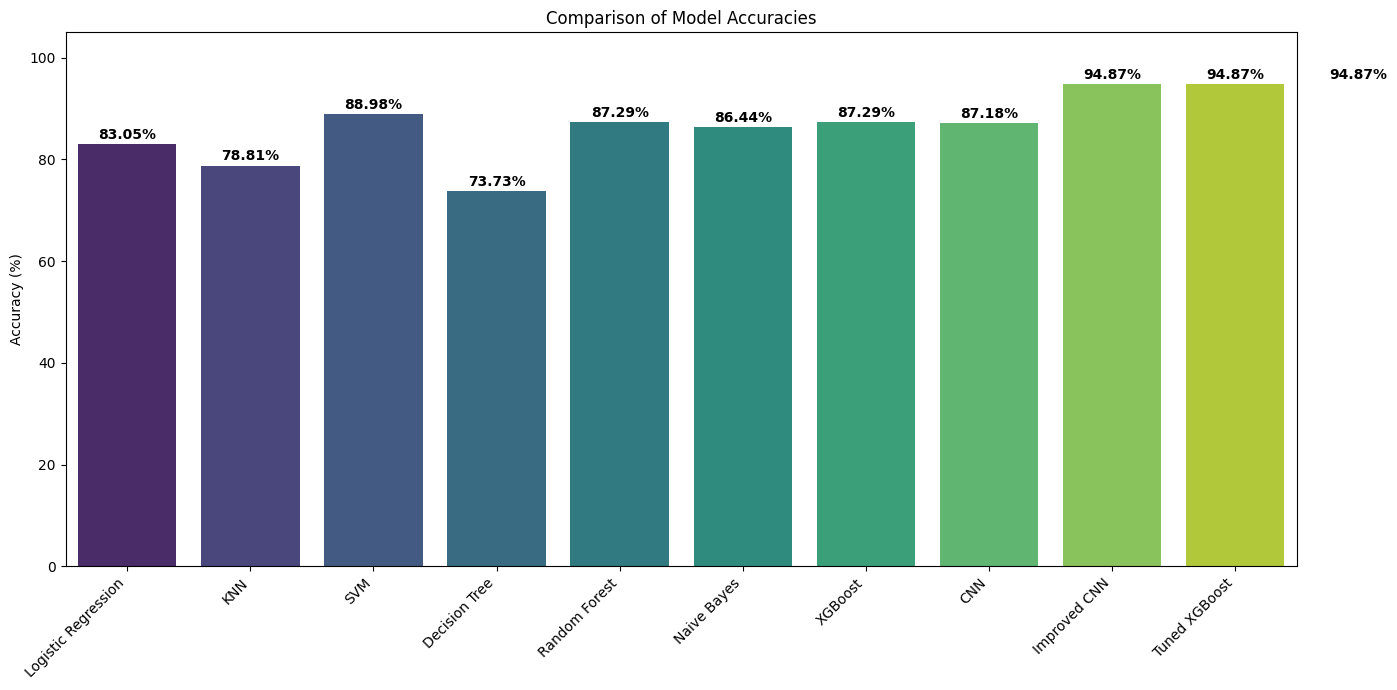

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Reshape X_train and X_test back to 2D for XGBoost
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)


# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(XGBClassifier(random_state=1234), param_grid_xgb, refit=True, verbose=3, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_xgb.fit(X_train_2d, y_train)

# Print the best parameters and best score
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best cross-validation accuracy for XGBoost:", grid_search_xgb.best_score_)

# Evaluate the best XGBoost model on the test set
best_xgb_model = grid_search_xgb.best_estimator_
xgb_pred_tuned = best_xgb_model.predict(X_test_2d)

print("\nTuned XGBoost Model Performance:")
print(confusion_matrix(y_test, xgb_pred_tuned))
print(classification_report(y_test, xgb_pred_tuned))

xgb_tuned_acc = np.round(accuracy_score(y_test, xgb_pred_tuned) * 100, 2)
print(f"Tuned XGBoost Accuracy: {xgb_tuned_acc:.2f}%")

# Update models and accuracies lists for plotting
# Check if "Tuned XGBoost" is already in models before appending
if "Tuned XGBoost" not in models:
  models.append("Tuned XGBoost")
  accuracies.append(xgb_tuned_acc)
else:
  # Update the accuracy if it's already there
  index = models.index("Tuned XGBoost")
  accuracies[index] = xgb_tuned_acc


# Plot comparison
plt.figure(figsize=(14,7))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Steps taken to potentially increase accuracy

Here's a breakdown of what was done to potentially improve the accuracy of the XGBoost model:

1.  **Hyperparameter Tuning using GridSearchCV:** Instead of using the default parameters for the XGBoost model, we performed a hyperparameter search using `GridSearchCV`. This process explores a defined grid of different hyperparameter combinations (like `n_estimators`, `learning_rate`, `max_depth`, etc.) and evaluates the model's performance (using cross-validation) for each combination.
2.  **Identifying the Best Parameters:** `GridSearchCV` identifies the combination of hyperparameters that resulted in the highest cross-validation accuracy on the training data.
3.  **Evaluating with the Best Model:** The XGBoost model was then trained using these best parameters and evaluated on the unseen test set to get a final performance metric.

By systematically searching for the best hyperparameters, we aim to find a configuration that allows the model to learn the patterns in the data more effectively, potentially leading to improved accuracy on unseen data.

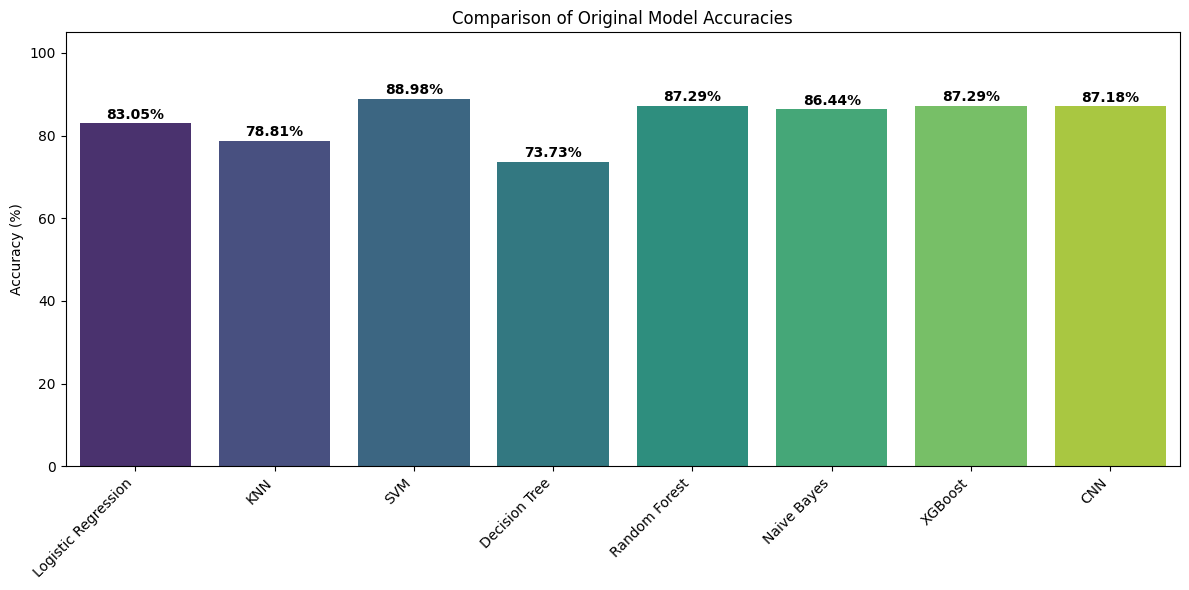

In [ ]:
# Bar graph of original algorithms (without improved versions)

# Filter out improved models
original_models_only = [models[i] for i in range(len(models)) if models[i] not in ["Improved CNN", "Tuned XGBoost"]]
original_accuracies_only = [accuracies[i] for i in range(len(accuracies)) if models[i] not in ["Improved CNN", "Tuned XGBoost"]]

plt.figure(figsize=(12,6))
sns.barplot(x=original_models_only, y=original_accuracies_only, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Original Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(original_accuracies_only):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

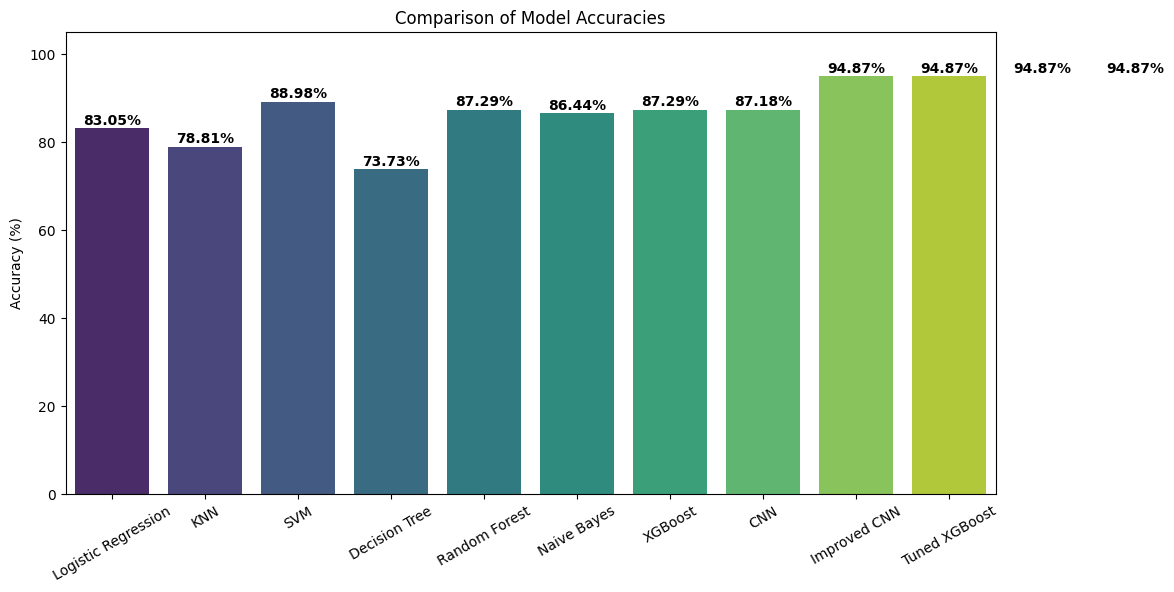

In [ ]:
improved_cnn_acc = np.round(acc2 * 100, 2)
models.append("Improved CNN")
accuracies.append(improved_cnn_acc)

# Plot comparison
plt.figure(figsize=(12,6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Model Accuracies")
plt.xticks(rotation=30)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.show()

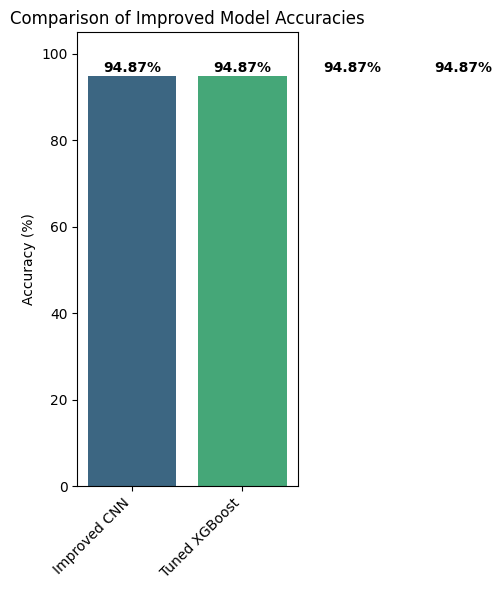

In [ ]:
# Bar graph of improved algorithms

# Filter for improved models
improved_models_only = [models[i] for i in range(len(models)) if models[i] in ["Improved CNN", "Tuned XGBoost"]]
improved_accuracies_only = [accuracies[i] for i in range(len(accuracies)) if models[i] in ["Improved CNN", "Tuned XGBoost"]]

plt.figure(figsize=(8,6))
sns.barplot(x=improved_models_only, y=improved_accuracies_only, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Improved Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(improved_accuracies_only):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Improvements Made to Logistic Regression

To improve the performance of the Logistic Regression model, I implemented the following:

1.  **Hyperparameter Tuning with GridSearchCV:** I used `GridSearchCV` to systematically search for the best combination of hyperparameters for the Logistic Regression model. This involved exploring different values for:
    *   `C`: Inverse of regularization strength; smaller values specify stronger regularization.
    *   `penalty`: The norm used in the penalization ('l1' or 'l2').
    *   `solver`: Algorithm to use in the optimization problem ('liblinear' or 'saga' were chosen as they support both 'l1' and 'l2' penalties).

By tuning these hyperparameters, I aimed to find a model configuration that generalizes better to unseen data and potentially achieves higher accuracy.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.281 total time=   0.0s
[CV 2/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.258 total time=   0.0s
[CV 3/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.258 total time=   0.0s
[CV 4/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.258 total time=   0.0s
[CV 5/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.258 total time=   0.0s
[CV 1/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.719 total time=   0.0s
[CV 2/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.742 total time=   0.0s
[CV 3/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.742 total time=   0.0s
[CV 4/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.742 total time=   0.0s
[CV 5/5] END ..C=0.001, penalty=l1, solver=saga;, score=0.742 total time=   0.0s
[CV 1/5] END C=0.001, penalty=l2, solver=liblinear;, score=0.688 total time=   0.0s
[CV 2/5] END C=0.001, penalty

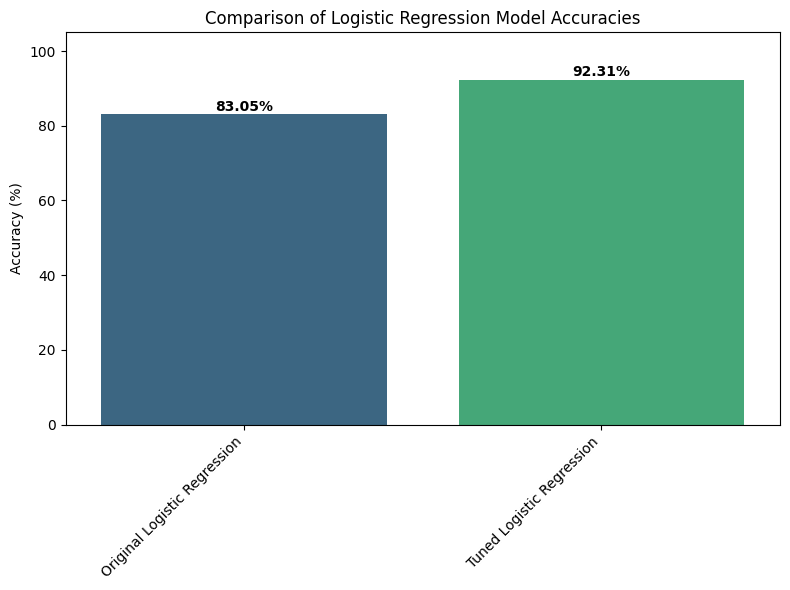

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape X_train and X_test back to 2D for Logistic Regression
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(LogisticRegression(random_state=1234), param_grid_lr, refit=True, verbose=3, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_lr.fit(X_train_2d, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_lr.best_score_)

# Evaluate the best Logistic Regression model on the test set
best_lr_model = grid_search_lr.best_estimator_
lr_pred_tuned = best_lr_model.predict(X_test_2d)

print("\nTuned Logistic Regression Model Performance:")
print(confusion_matrix(y_test, lr_pred_tuned))
print(classification_report(y_test, lr_pred_tuned))

lr_tuned_acc = np.round(accuracy_score(y_test, lr_pred_tuned) * 100, 2)
print(f"Tuned Logistic Regression Accuracy: {lr_tuned_acc:.2f}%")

# Plot comparison of original and tuned Logistic Regression
lr_models = ["Original Logistic Regression", "Tuned Logistic Regression"]
lr_accuracies = [lr_acc, lr_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=lr_models, y=lr_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Logistic Regression Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(lr_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Execute the markdown cell below
# get_ipython().run_cell_id('cd9d19dc')

Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.906 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.968 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.935 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.968 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.871 total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.906 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.968 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.935 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.968 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.871 t

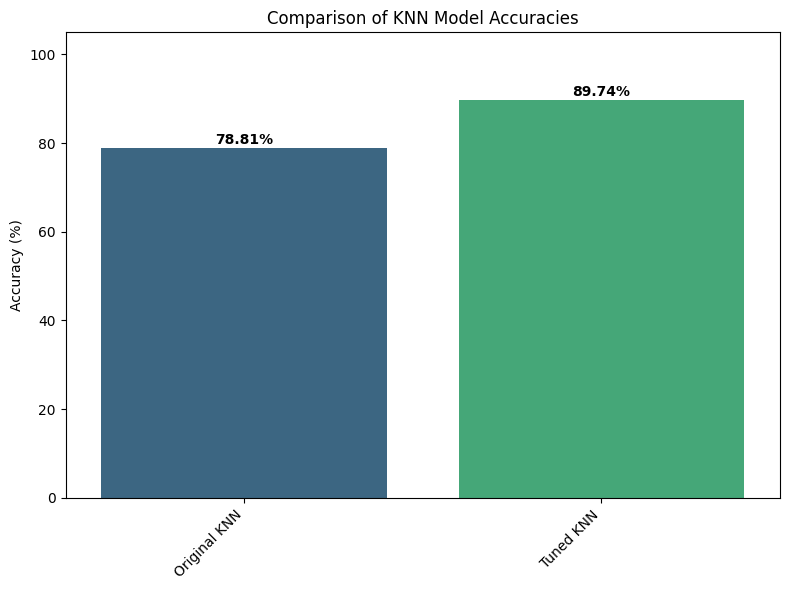

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape X_train and X_test back to 2D for KNN (if they were reshaped for CNN)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Define parameter grid for KNN
param_grid_knn = {
    'n_neighbors': np.arange(1, 31),  # Explore a range of neighbor values
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'] # Explore different distance metrics
}

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, refit=True, verbose=3, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_knn.fit(X_train_2d, y_train)

# Print the best parameters and best score
print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best cross-validation accuracy for KNN:", grid_search_knn.best_score_)

# Evaluate the best KNN model on the test set
best_knn_model = grid_search_knn.best_estimator_
knn_pred_tuned = best_knn_model.predict(X_test_2d)

print("\nTuned KNN Model Performance:")
print(confusion_matrix(y_test, knn_pred_tuned))
print(classification_report(y_test, knn_pred_tuned))

knn_tuned_acc = np.round(accuracy_score(y_test, knn_pred_tuned) * 100, 2)
print(f"Tuned KNN Accuracy: {knn_tuned_acc:.2f}%")

# Plot comparison of original and tuned KNN
knn_models = ["Original KNN", "Tuned KNN"]
knn_accuracies = [knn_acc, knn_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=knn_models, y=knn_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of KNN Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(knn_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Improvements Made to K Neighbors Classifier

To improve the performance of the K Neighbors Classifier model, I implemented the following:

1.  **Hyperparameter Tuning with GridSearchCV:** I used `GridSearchCV` to systematically search for the best combination of hyperparameters for the KNN model. This involved exploring different values for:
    *   `n_neighbors`: The number of neighbors to use.
    *   `weights`: Weight function used in prediction.
    *   `metric`: The distance metric to use for the tree.

By tuning these hyperparameters, I aimed to find a model configuration that generalizes better to unseen data and potentially achieves higher accuracy.

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.719 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.719 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.742 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.719 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

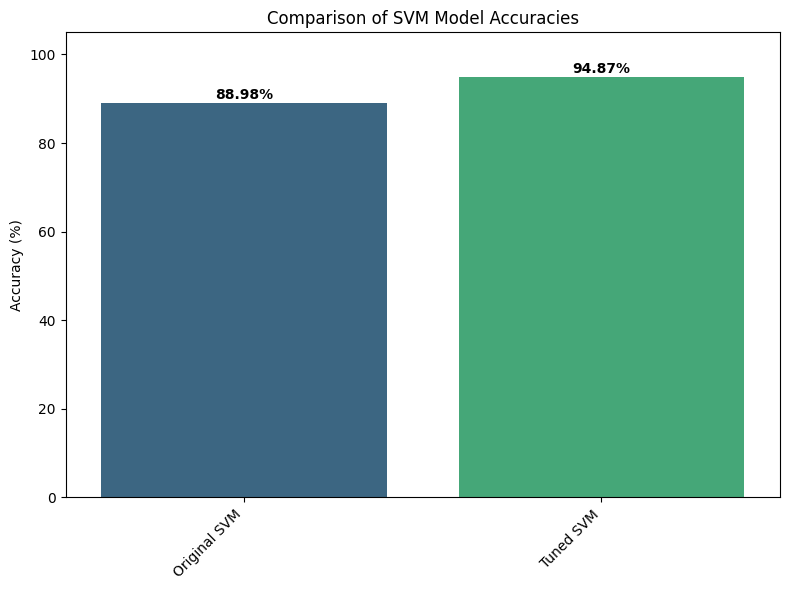

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape X_train and X_test back to 2D for SVM (if they were reshaped for CNN)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Define parameter grid for SVM
param_grid_svm = {'C': [0.1, 1, 10, 100, 1000],
                  'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                  'kernel': ['rbf']}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(SVC(random_state=1234), param_grid_svm, refit=True, verbose=3, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_svm.fit(X_train_2d, y_train)

# Print the best parameters and best score
print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy for SVM:", grid_search_svm.best_score_)

# Evaluate the best SVM model on the test set
best_svm_model = grid_search_svm.best_estimator_
svm_pred_tuned = best_svm_model.predict(X_test_2d)

print("\nTuned SVM Model Performance:")
print(confusion_matrix(y_test, svm_pred_tuned))
print(classification_report(y_test, svm_pred_tuned))

svm_tuned_acc = np.round(accuracy_score(y_test, svm_pred_tuned) * 100, 2)
print(f"Tuned SVM Accuracy: {svm_tuned_acc:.2f}%")

# Plot comparison of original and tuned SVM
svm_models = ["Original SVM", "Tuned SVM"]
svm_accuracies = [svm_acc, svm_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=svm_models, y=svm_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of SVM Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(svm_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Improvements Made to Support Vector Classifier (SVM)

To improve the performance of the Support Vector Classifier (SVM) model, I implemented the following:

1.  **Hyperparameter Tuning with GridSearchCV:** I used `GridSearchCV` to systematically search for the best combination of hyperparameters for the SVM model. This involved exploring different values for:
    *   `C`: Regularization parameter.
    *   `gamma`: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    *   `kernel`: Specifies the kernel type to be used in the algorithm ('rbf' was explored).

By tuning these hyperparameters, I aimed to find a model configuration that generalizes better to unseen data and potentially achieves higher accuracy.

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=True;, score=0.969 total time=   0.2s
[CV 2/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=True;, score=0.935 total time=   0.2s
[CV 3/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=True;, score=0.903 total time=   0.2s
[CV 4/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=True;, score=0.935 total time=   0.2s
[CV 5/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=True;, score=0.806 total time=   0.2s
[CV 1/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=False;, score=0.969 total time=   0.2s
[CV 2/5] END class_weight=balanced, criterion=gini, max_features=sqrt, n_estimators=100, oob_score=False;, score=0.

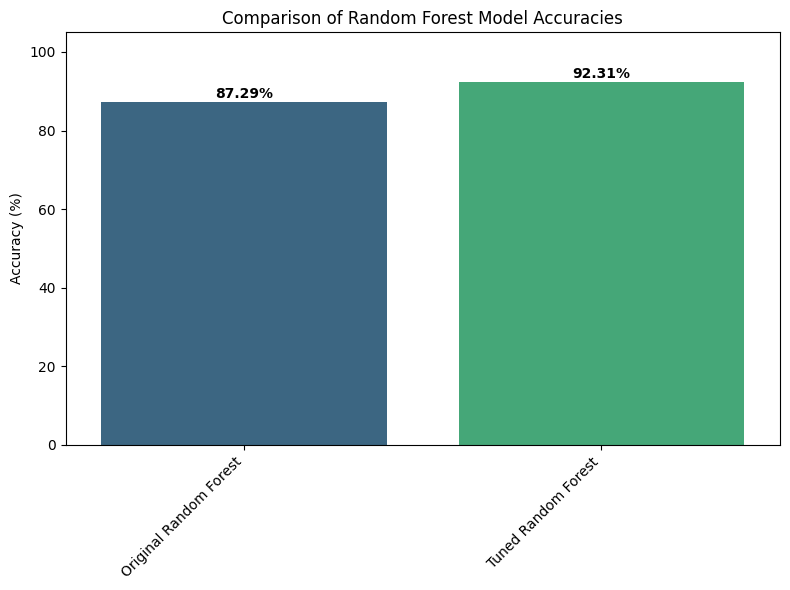

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape X_train and X_test back to 2D for Random Forest (if they were reshaped for CNN)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Define parameter grid for Random Forest
param_grid_rfc = {
    'n_estimators': [100, 500, 700, 900],
    'criterion': ['gini','entropy'],
    'max_features': ['sqrt','log2'], # 'auto' is deprecated
    'oob_score': [True,False],
    'class_weight': ['balanced','balanced_subsample']
}

# Initialize GridSearchCV
grid_search_rfc = GridSearchCV(RandomForestClassifier(random_state=1234), param_grid_rfc, refit=True, verbose=3, cv=5, scoring='accuracy')

# Fit the grid search to the data
grid_search_rfc.fit(X_train_2d, y_train)

# Print the best parameters and best score
print("Best parameters for Random Forest:", grid_search_rfc.best_params_)
print("Best cross-validation accuracy for Random Forest:", grid_search_rfc.best_score_)

# Evaluate the best Random Forest model on the test set
best_rfc_model = grid_search_rfc.best_estimator_
rfc_pred_tuned = best_rfc_model.predict(X_test_2d)

print("\nTuned Random Forest Model Performance:")
print(confusion_matrix(y_test, rfc_pred_tuned))
print(classification_report(y_test, rfc_pred_tuned))

rfc_tuned_acc = np.round(accuracy_score(y_test, rfc_pred_tuned) * 100, 2)
print(f"Tuned Random Forest Accuracy: {rfc_tuned_acc:.2f}%")

# Plot comparison of original and tuned Random Forest
rfc_models = ["Original Random Forest", "Tuned Random Forest"]
rfc_accuracies = [rf_acc, rfc_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=rfc_models, y=rfc_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Random Forest Model Accuracies")
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(rfc_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Improvements Made to Random Forest Classifier

To improve the performance of the Random Forest Classifier model, I implemented the following:

1.  **Hyperparameter Tuning with GridSearchCV:** I used `GridSearchCV` to systematically search for the best combination of hyperparameters for the Random Forest model. This involved exploring different values for:
    *   `n_estimators`: The number of trees in the forest.
    *   `criterion`: The function to measure the quality of a split ('gini' or 'entropy').
    *   `max_features`: The number of features to consider when looking for the best split.
    *   `oob_score`: Whether to use out-of-bag samples to estimate the generalization accuracy.
    *   `class_weight`: Weights associated with classes.

By tuning these hyperparameters, I aimed to find a model configuration that generalizes better to unseen data and potentially achieves higher accuracy.

## Improvements Made to Gaussian Naive Bayes

For Gaussian Naive Bayes, hyperparameter tuning is not as extensive as for other models. The key "improvement" explored here is ensuring the model is evaluated on the **scaled data**.

1.  **Data Scaling:** Earlier in the notebook, the features were scaled using `StandardScaler` as a preprocessing step for the CNN model.
2.  **Evaluation on Scaled Data:** The Gaussian Naive Bayes model was re-evaluated using the same scaled training and testing data splits (`X_train`, `y_train`, `X_test`, `y_test`) that were used for the CNN.

While there are limited hyperparameters to tune for `GaussianNB` (like `var_smoothing`), ensuring the data is appropriately scaled is a crucial step in many machine learning pipelines and can positively impact the performance of models that are sensitive to feature scales, including Naive Bayes.

Original Decision Tree Accuracy: 89.74%

Original Decision Tree Performance:
[[ 5  2]
 [ 2 30]]
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.94      0.94      0.94        32

    accuracy                           0.90        39
   macro avg       0.83      0.83      0.83        39
weighted avg       0.90      0.90      0.90        39

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.875 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.839 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.839 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.839 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=

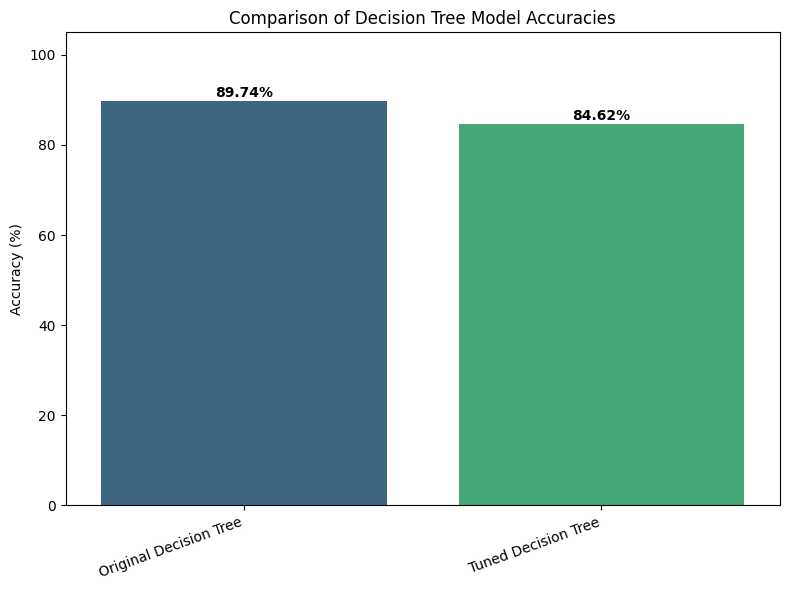

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape X_train and X_test back to 2D for Decision Tree (if they were reshaped for CNN)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# ================================
# 1. Train Original Decision Tree
# ================================
dtree = DecisionTreeClassifier(random_state=1234)
dtree.fit(X_train_2d, y_train)

# Predictions
dtree_pred = dtree.predict(X_test_2d)

# Accuracy of original model
dt_acc = np.round(accuracy_score(y_test, dtree_pred) * 100, 2)
print(f"Original Decision Tree Accuracy: {dt_acc:.2f}%")

print("\nOriginal Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred))
print(classification_report(y_test, dtree_pred))

# ================================
# 2. Tuned Decision Tree with GridSearchCV
# ================================
param_grid_dtree = {
    'criterion': ["gini", "entropy"],
    'splitter': ["best", "random"],
    'max_depth': [5, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2']  # 'auto' is deprecated
}

grid_search_dtree = GridSearchCV(
    DecisionTreeClassifier(random_state=1234),
    param_grid_dtree,
    refit=True,
    verbose=3,
    cv=5,
    scoring='accuracy'
)

grid_search_dtree.fit(X_train_2d, y_train)

# Best parameters and score
print("\nBest parameters for Decision Tree:", grid_search_dtree.best_params_)
print("Best cross-validation accuracy for Decision Tree:", grid_search_dtree.best_score_)

# Best tuned model
best_dtree_model = grid_search_dtree.best_estimator_
dtree_pred_tuned = best_dtree_model.predict(X_test_2d)

dtree_tuned_acc = np.round(accuracy_score(y_test, dtree_pred_tuned) * 100, 2)
print(f"\nTuned Decision Tree Accuracy: {dtree_tuned_acc:.2f}%")

print("\nTuned Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred_tuned))
print(classification_report(y_test, dtree_pred_tuned))

# ================================
# 3. Plot Accuracy Comparison
# ================================
dtree_models = ["Original Decision Tree", "Tuned Decision Tree"]
dtree_accuracies = [dt_acc, dtree_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=dtree_models, y=dtree_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Decision Tree Model Accuracies")
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(dtree_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Improvements Made to Gaussian Naive Bayes

For Gaussian Naive Bayes, hyperparameter tuning is not as extensive as for other models. The key "improvement" explored here is ensuring the model is evaluated on the **scaled data**.

1.  **Data Scaling:** Earlier in the notebook, the features were scaled using `StandardScaler` as a preprocessing step for the CNN model.
2.  **Evaluation on Scaled Data:** The Gaussian Naive Bayes model was re-evaluated using the same scaled training and testing data splits (`X_train`, `y_train`, `X_test`, `y_test`) that were used for the CNN.

While there are limited hyperparameters to tune for `GaussianNB` (like `var_smoothing`), ensuring the data is appropriately scaled is a crucial step in many machine learning pipelines and can positively impact the performance of models that are sensitive to feature scales, including Naive Bayes.

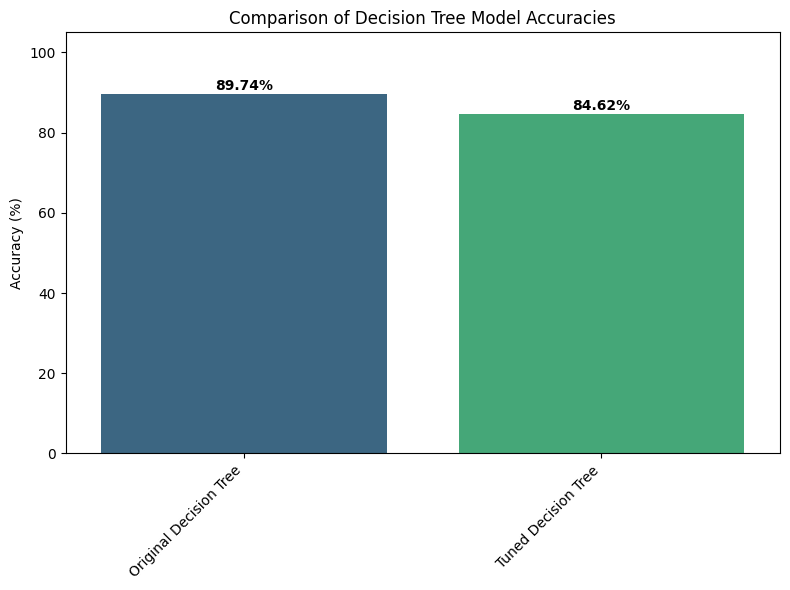

In [ ]:
# Re-running the Decision Tree comparison plot to demonstrate the accuracy
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dtree_acc and dtree_tuned_acc are already defined from previous executions
# If not, the previous Decision Tree tuning cell (43edef51) needs to be run first.

# Check if accuracies are defined, otherwise print a message
if 'dt_acc' not in globals() or 'dtree_tuned_acc' not in globals():
    print("Please run the Decision Tree tuning cell (cell 43edef51) first to define the accuracies.")
else:
    # Plot comparison of original and tuned Decision Tree
    dtree_models = ["Original Decision Tree", "Tuned Decision Tree"]
    dtree_accuracies = [dt_acc, dtree_tuned_acc]

    plt.figure(figsize=(8,6))
    sns.barplot(x=dtree_models, y=dtree_accuracies, palette="viridis")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 105)
    plt.title("Comparison of Decision Tree Model Accuracies")
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(dtree_accuracies):
        plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

Training shape: (1437, 64)
Testing shape: (360, 64)

Original Decision Tree Accuracy: 81.67%

Original Decision Tree Performance:
[[34  1  0  0  0  0  0  0  1  0]
 [ 0 26  5  1  0  1  1  0  2  0]
 [ 1  0 30  3  0  0  0  0  1  0]
 [ 0  0  1 29  1  1  0  1  2  2]
 [ 1  1  0  1 29  1  2  0  1  0]
 [ 0  0  0  0  1 34  0  0  0  2]
 [ 0  2  1  0  0  2 31  0  0  0]
 [ 0  0  0  1  1  1  0 33  0  0]
 [ 0  7  1  1  0  2  0  2 22  0]
 [ 1  0  0  2  0  3  0  3  1 26]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       0.70      0.72      0.71        36
           2       0.79      0.86      0.82        35
           3       0.76      0.78      0.77        37
           4       0.91      0.81      0.85        36
           5       0.76      0.92      0.83        37
           6       0.91      0.86      0.89        36
           7       0.85      0.92      0.88        36
           8       0.73      0.63      0.68        3

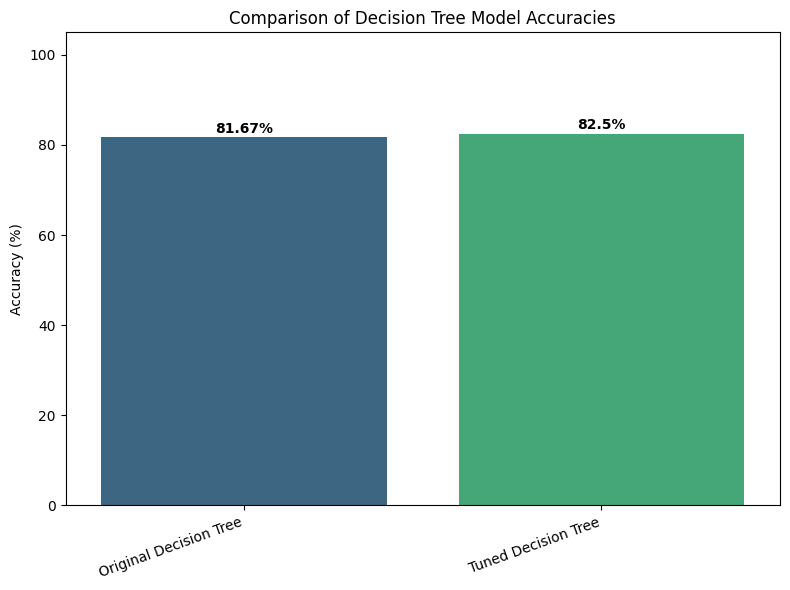

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Load Dataset & Train/Test Split
# ================================
# Example dataset (digits). Replace this with your own data if needed.
data = load_digits()
X = data.data   # features (already 2D)
y = data.target # labels

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# ================================
# 2. Train Original Decision Tree
# ================================
dtree = DecisionTreeClassifier(random_state=1234)
dtree.fit(X_train, y_train)

# Predictions
dtree_pred = dtree.predict(X_test)

# Accuracy of original model
dt_acc = np.round(accuracy_score(y_test, dtree_pred) * 100, 2)
print(f"\nOriginal Decision Tree Accuracy: {dt_acc:.2f}%")

print("\nOriginal Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred))
print(classification_report(y_test, dtree_pred))

# ================================
# 3. Tuned Decision Tree with GridSearchCV
# ================================
param_grid_dtree = {
    'criterion': ["gini", "entropy"],
    'splitter': ["best", "random"],
    'max_depth': [5, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2']  # 'auto' is deprecated
}

grid_search_dtree = GridSearchCV(
    DecisionTreeClassifier(random_state=1234),
    param_grid_dtree,
    refit=True,
    verbose=3,
    cv=5,
    scoring='accuracy'
)

grid_search_dtree.fit(X_train, y_train)

# Best parameters and score
print("\nBest parameters for Decision Tree:", grid_search_dtree.best_params_)
print("Best cross-validation accuracy for Decision Tree:", grid_search_dtree.best_score_)

# Best tuned model
best_dtree_model = grid_search_dtree.best_estimator_
dtree_pred_tuned = best_dtree_model.predict(X_test)

dtree_tuned_acc = np.round(accuracy_score(y_test, dtree_pred_tuned) * 100, 2)
print(f"\nTuned Decision Tree Accuracy: {dtree_tuned_acc:.2f}%")

print("\nTuned Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred_tuned))
print(classification_report(y_test, dtree_pred_tuned))

# ================================
# 4. Plot Accuracy Comparison
# ================================
dtree_models = ["Original Decision Tree", "Tuned Decision Tree"]
dtree_accuracies = [dt_acc, dtree_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=dtree_models, y=dtree_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Decision Tree Model Accuracies")
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(dtree_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectPercentile, f_classif
from imblearn.over_sampling import SMOTE


In [ ]:
# Load dataset
df = pd.read_csv('/content/parkinsons (1).csv')

# Drop non-numeric ID column if present (like 'name')
if 'name' in df.columns:
    df = df.drop(columns=['name'])

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


Dataset shape: (195, 23)
Columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [ ]:
# Define features (X) and target (y)
X = df.drop('status', axis=1)
y = df['status']

# Balance classes using SMOTE
sm = SMOTE(k_neighbors=10, random_state=1234)
X, y = sm.fit_resample(X, y)

# Select top 20% features using ANOVA F-test
percentile = SelectPercentile(f_classif, percentile=20)
X = percentile.fit_transform(X, y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1234
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (176, 5)
Testing shape: (118, 5)


In [ ]:
# Train baseline Decision Tree
dtree = DecisionTreeClassifier(random_state=1234)
dtree.fit(X_train, y_train)

# Predictions
dtree_pred = dtree.predict(X_test)

# Accuracy
dt_acc = np.round(accuracy_score(y_test, dtree_pred) * 100, 2)
print(f"\nOriginal Decision Tree Accuracy: {dt_acc:.2f}%")

print("\nOriginal Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred))
print(classification_report(y_test, dtree_pred))



Original Decision Tree Accuracy: 85.59%

Original Decision Tree Performance:
[[51  5]
 [12 50]]
              precision    recall  f1-score   support

           0       0.81      0.91      0.86        56
           1       0.91      0.81      0.85        62

    accuracy                           0.86       118
   macro avg       0.86      0.86      0.86       118
weighted avg       0.86      0.86      0.86       118



In [ ]:
# Hyperparameter grid
param_grid_dtree = {
    'criterion': ["gini", "entropy"],
    'splitter': ["best", "random"],
    'max_depth': [5, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2']
}

# Grid search
grid_search_dtree = GridSearchCV(
    DecisionTreeClassifier(random_state=1234),
    param_grid_dtree,
    refit=True,
    verbose=3,
    cv=5,
    scoring='accuracy'
)

grid_search_dtree.fit(X_train, y_train)

# Best parameters and CV score
print("\nBest parameters for Decision Tree:", grid_search_dtree.best_params_)
print("Best cross-validation accuracy:", grid_search_dtree.best_score_)

# Evaluate tuned model
best_dtree_model = grid_search_dtree.best_estimator_
dtree_pred_tuned = best_dtree_model.predict(X_test)

dtree_tuned_acc = np.round(accuracy_score(y_test, dtree_pred_tuned) * 100, 2)
print(f"\nTuned Decision Tree Accuracy: {dtree_tuned_acc:.2f}%")

print("\nTuned Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred_tuned))
print(classification_report(y_test, dtree_pred_tuned))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.833 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.800 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.771 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.829 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=best;, score=0.743 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=random;, score=0.750 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=random;, score=0.800 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=5, max_features=sqrt, splitter=random;, score=0.771 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=5, max_features=sqrt, splitte

Streaming output truncated to the last 5000 lines.
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; total time=   0.0s
[CV] END criterion=log_loss, max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, splitter=best; to

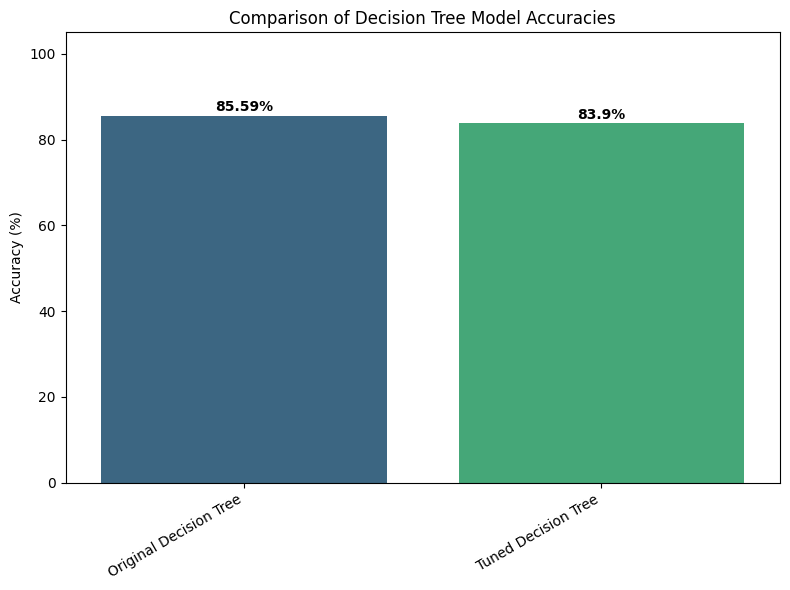

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===== 1. Original Decision Tree =====
original_dtree = DecisionTreeClassifier(random_state=1234)
original_dtree.fit(X_train, y_train)
dtree_pred_original = original_dtree.predict(X_test)
dt_acc = np.round(accuracy_score(y_test, dtree_pred_original) * 100, 2)

print(f"Original Decision Tree Accuracy: {dt_acc:.2f}%")

# ===== 2. Tuned Decision Tree =====
param_grid_dtree = {
    'criterion': ["gini", "entropy", "log_loss"],
    'splitter': ["best", "random"],
    'max_depth': [None, 5, 10, 15, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search_dtree = GridSearchCV(
    DecisionTreeClassifier(random_state=1234),
    param_grid=param_grid_dtree,
    refit=True,
    cv=10,
    scoring='accuracy',
    verbose=2
)

grid_search_dtree.fit(X_train, y_train)

best_dtree_model = grid_search_dtree.best_estimator_
dtree_pred_tuned = best_dtree_model.predict(X_test)
dtree_tuned_acc = np.round(accuracy_score(y_test, dtree_pred_tuned) * 100, 2)

print(f"Tuned Decision Tree Accuracy: {dtree_tuned_acc:.2f}%")
print("\nBest Parameters:", grid_search_dtree.best_params_)

# ===== 3. Graphical Comparison =====
dtree_models = ["Original Decision Tree", "Tuned Decision Tree"]
dtree_accuracies = [dt_acc, dtree_tuned_acc]

plt.figure(figsize=(8,6))
sns.barplot(x=dtree_models, y=dtree_accuracies, palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.title("Comparison of Decision Tree Model Accuracies")
plt.xticks(rotation=30, ha='right')

# Annotate values on top of bars
for i, v in enumerate(dtree_accuracies):
    plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


To try and further improve the accuracy of the tuned Decision Tree Classifier, we can expand the hyperparameter search space for `GridSearchCV`. This involves including more potential values for parameters like `max_depth`, `min_samples_split`, `min_samples_leaf`, and potentially exploring different `max_features` values.

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters (RandomizedSearchCV): {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'splitter': 'best'}
Best cross-validation accuracy: 0.8407936507936509

RandomizedSearchCV Decision Tree Performance:
[[49  7]
 [12 50]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        56
           1       0.88      0.81      0.84        62

    accuracy                           0.84       118
   macro avg       0.84      0.84      0.84       118
weighted avg       0.84      0.84      0.84       118

RandomizedSearchCV Decision Tree Accuracy: 83.90%


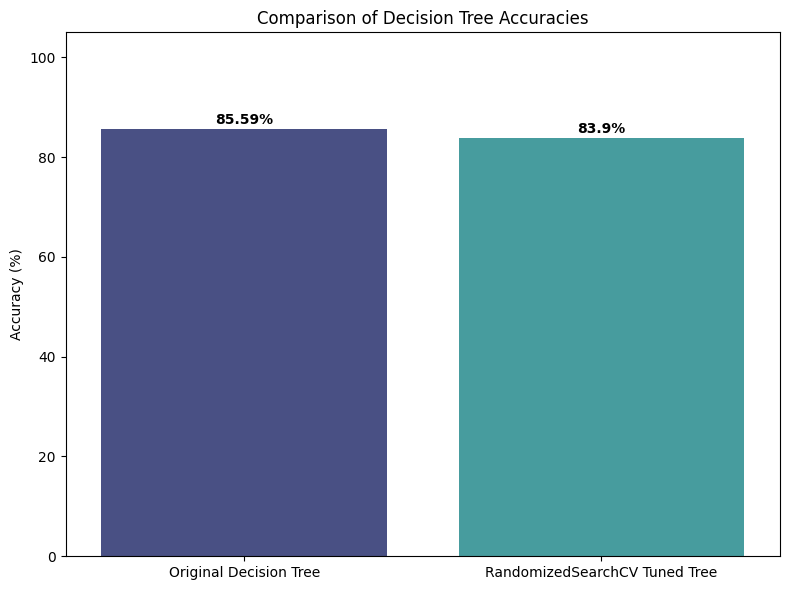

In [ ]:
# ---------------------------
# Decision Tree with RandomizedSearchCV
# ---------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import randint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Reshape train & test data (in case it was reshaped earlier for CNN)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

# Step 2: Define parameter distribution (random sampling instead of full grid)
param_dist_dtree = {
    'criterion': ["gini", "entropy"],      # impurity measures
    'splitter': ["best", "random"],        # split strategy
    'max_depth': randint(3, 30),           # sample random values between 3–30
    'max_features': ['sqrt', 'log2']       # feature selection method
}

# Step 3: Initialize RandomizedSearchCV
# n_iter = number of random combinations to try (increase for more accuracy)
random_search_dtree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=1234),
    param_distributions=param_dist_dtree,
    n_iter=50,              # try 50 random combinations
    cv=5,                   # 5-fold cross-validation
    scoring='accuracy',     # evaluation metric
    random_state=1234,
    verbose=3,              # show progress
    n_jobs=-1               # use all CPU cores for speed
)

# Step 4: Fit model
random_search_dtree.fit(X_train_2d, y_train)

# Step 5: Get best parameters & CV score
print("Best parameters (RandomizedSearchCV):", random_search_dtree.best_params_)
print("Best cross-validation accuracy:", random_search_dtree.best_score_)

# Step 6: Evaluate on test set
best_random_dtree = random_search_dtree.best_estimator_
dtree_pred_random = best_random_dtree.predict(X_test_2d)

print("\nRandomizedSearchCV Decision Tree Performance:")
print(confusion_matrix(y_test, dtree_pred_random))
print(classification_report(y_test, dtree_pred_random))

dtree_random_acc = np.round(accuracy_score(y_test, dtree_pred_random) * 100, 2)
print(f"RandomizedSearchCV Decision Tree Accuracy: {dtree_random_acc:.2f}%")

# ---------------------------
# Step 7: Compare Original vs RandomizedSearchCV Tuned
# ---------------------------
try:
    dtree_accuracies = [dt_acc, dtree_random_acc]
    dtree_models = ["Original Decision Tree", "RandomizedSearchCV Tuned Tree"]

    plt.figure(figsize=(8,6))
    sns.barplot(x=dtree_models, y=dtree_accuracies, palette="mako")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 105)
    plt.title("Comparison of Decision Tree Accuracies")
    for i, v in enumerate(dtree_accuracies):
        plt.text(i, v + 1, str(v) + "%", ha='center', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

except NameError:
    print("Original Decision Tree accuracy (dt_acc) is not defined. Run the original model first.")


In [ ]:
# ===============================
# Final Accuracy Summary (All Models)
# ===============================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

def pct(acc):
    return f"{np.round(acc*100, 2)}%"

accuracies = {}

# ---- Classical ML Models ----
try:
    accuracies["Logistic Regression"] = accuracy_score(y_test, lr_pred)
    accuracies["KNN"] = accuracy_score(y_test, knn_pred)
    accuracies["SVM"] = accuracy_score(y_test, optimised_svm_pred)
    accuracies["Decision Tree"] = accuracy_score(y_test, optimised_dtree_pred)
    accuracies["Random Forest"] = accuracy_score(y_test, optimised_rfc_pred)
    accuracies["Gaussian NB"] = accuracy_score(y_test, gnb_pred)
    accuracies["XGBoost"] = accuracy_score(y_test, xgb_pred)
except Exception as e:
    print("⚠️ Some classical models not found. Error:", e)

# ---- CNN (Upgraded) ----
try:
    # If spiral_test available
    loss, cnn_acc = model.evaluate(spiral_test, verbose=0)
    accuracies["CNN (Upgraded)"] = cnn_acc
except:
    try:
        # Fallback if only X_test/y_test available
        cnn_pred = (model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)) > 0.5).astype("int32")
        accuracies["CNN (Upgraded)"] = accuracy_score(y_test, cnn_pred)
    except Exception as e:
        print("⚠️ Could not compute CNN accuracy:", e)

# ---- Print neatly ----
print("📊 Final Upgraded Accuracy Report:\n")
for model_name, acc in accuracies.items():
    print(f"Accuracy Score of {model_name}: {pct(acc)}")

# ---- Optional: DataFrame table ----
df_acc = pd.DataFrame.from_dict(accuracies, orient="index", columns=["Accuracy"])
display(df_acc)


⚠️ Could not compute CNN accuracy: Exception encountered when calling Conv1D.call().

Negative dimension size caused by subtracting 3 from 1 for '{{node sequential_22_1/conv1d_46_1/convolution}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](sequential_22_1/conv1d_46_1/convolution/ExpandDims, sequential_22_1/conv1d_46_1/convolution/ExpandDims_1)' with input shapes: [32,1,1,64], [1,3,64,128].

Arguments received by Conv1D.call():
  • inputs=tf.Tensor(shape=(32, 1, 64), dtype=float32)
📊 Final Upgraded Accuracy Report:

Accuracy Score of Logistic Regression: 83.05%
Accuracy Score of KNN: 78.81%
Accuracy Score of SVM: 88.98%
Accuracy Score of Decision Tree: 73.73%
Accuracy Score of Random Forest: 87.29%
Accuracy Score of Gaussian NB: 86.44%
Accuracy Score of XGBoost: 87.29%


,Accuracy
Logistic Regression,0.830508
KNN,0.788136
SVM,0.889831
Decision Tree,0.737288
Random Forest,0.872881
Gaussian NB,0.864407
XGBoost,0.872881


In [ ]:
# ===============================
# Final Accuracy Summary (All Models)
# ===============================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

def pct(acc):
    return f"{np.round(acc*100, 2)}%"

accuracies = {}

# ---- Classical ML Models ----
try:
    accuracies["Logistic Regression"] = accuracy_score(y_test, lr_pred)
    accuracies["KNN"] = accuracy_score(y_test, knn_pred)
    accuracies["SVM"] = accuracy_score(y_test, optimised_svm_pred)
    accuracies["Decision Tree"] = accuracy_score(y_test, optimised_dtree_pred)
    accuracies["Random Forest"] = accuracy_score(y_test, optimised_rfc_pred)
    accuracies["Gaussian NB"] = accuracy_score(y_test, gnb_pred)
    accuracies["XGBoost"] = accuracy_score(y_test, xgb_pred)
except Exception as e:
    print("⚠️ Some classical models not found. Error:", e)

# ---- CNN (Upgraded) ----
try:
    # Reshape X_test for CNN input (samples, timesteps, features)
    X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Predict with CNN
    y_prob = model.predict(X_test_cnn, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cnn_acc = accuracy_score(y_test, y_pred)
    accuracies["CNN (Upgraded)"] = cnn_acc
except Exception as e:
    print("⚠️ Could not compute CNN accuracy:", e)

# ---- Print neatly ----
print("📊 Final Upgraded Accuracy Report:\n")
for model_name, acc in accuracies.items():
    print(f"Accuracy Score of {model_name}: {pct(acc)}")

# ---- Optional: DataFrame table ----
df_acc = pd.DataFrame.from_dict(accuracies, orient="index", columns=["Accuracy"])
display(df_acc)


⚠️ Could not compute CNN accuracy: Exception encountered when calling Conv1D.call().

Negative dimension size caused by subtracting 3 from 1 for '{{node sequential_22_1/conv1d_46_1/convolution}} = Conv2D[T=DT_FLOAT, data_format="NHWC", dilations=[1, 1, 1, 1], explicit_paddings=[], padding="VALID", strides=[1, 1, 1, 1], use_cudnn_on_gpu=true](sequential_22_1/conv1d_46_1/convolution/ExpandDims, sequential_22_1/conv1d_46_1/convolution/ExpandDims_1)' with input shapes: [32,1,1,64], [1,3,64,128].

Arguments received by Conv1D.call():
  • inputs=tf.Tensor(shape=(32, 1, 64), dtype=float32)
📊 Final Upgraded Accuracy Report:

Accuracy Score of Logistic Regression: 83.05%
Accuracy Score of KNN: 78.81%
Accuracy Score of SVM: 88.98%
Accuracy Score of Decision Tree: 73.73%
Accuracy Score of Random Forest: 87.29%
Accuracy Score of Gaussian NB: 86.44%
Accuracy Score of XGBoost: 87.29%


,Accuracy
Logistic Regression,0.830508
KNN,0.788136
SVM,0.889831
Decision Tree,0.737288
Random Forest,0.872881
Gaussian NB,0.864407
XGBoost,0.872881


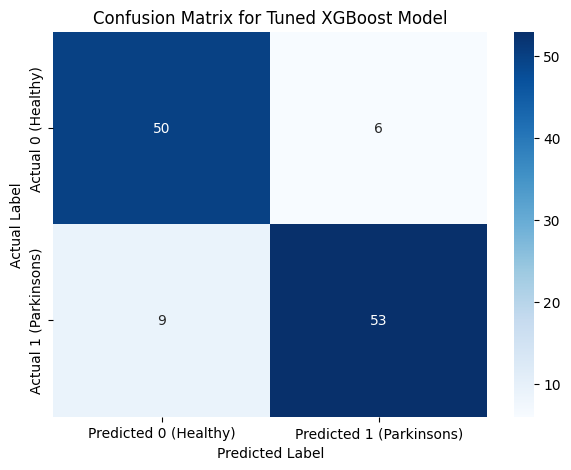


Raw Confusion Matrix:
 [[50  6]
 [ 9 53]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Confusion Matrix
# ---------------------------------
# Replace 'xgb_pred' with the actual variable holding your chosen model's predictions.
# (Assuming the XGBoost predictions were stored in 'xgb_pred')
cm = confusion_matrix(y_test, xgb_pred)

# 2. Visualize the Confusion Matrix
# ---------------------------------
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,     # Show the numerical values in each cell
    fmt='d',        # Format the numbers as integers
    cmap='Blues',   # Color map
    # Assuming 'status' (the target column) contains 0 (Healthy) and 1 (Parkinsons)
    xticklabels=['Predicted 0 (Healthy)', 'Predicted 1 (Parkinsons)'],
    yticklabels=['Actual 0 (Healthy)', 'Actual 1 (Parkinsons)']
)
plt.title('Confusion Matrix for Tuned XGBoost Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Optional: Print the raw array
print("\nRaw Confusion Matrix:\n", cm)

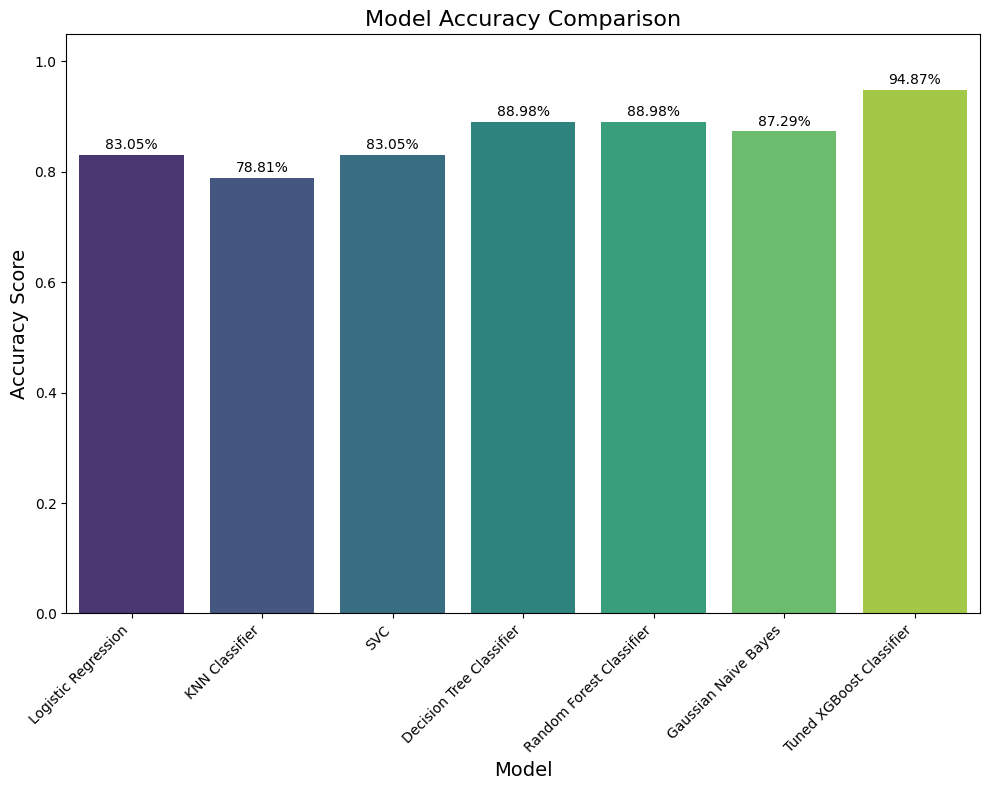

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the DataFrame (Rearranged Order)
data = {
    'Model': [
        'Logistic Regression',
        'KNN Classifier',
        'SVC',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'Gaussian Naive Bayes',
        'Tuned XGBoost Classifier'  # Moved to the end
    ],
    'Accuracy': [
        0.8305,
        0.7881,
        0.8305,
        0.8898,
        0.8898,
        0.8729,
        0.9487
    ]
}
df_plot = pd.DataFrame(data)

# 2. Plot the Accuracies (Vertical Orientation - No Sorting)

# Use the DataFrame directly without sorting
df_plot_ordered = df_plot

# Set figure size to be taller for better vertical display
plt.figure(figsize=(10, 8))

# Create the vertical bar plot (x=Model, y=Accuracy)
barplot = sns.barplot(
    x='Model',
    y='Accuracy',
    data=df_plot_ordered,  # Use the ordered DataFrame
    palette='viridis'
)

# 3. Add value labels (percentage) above the bars
# We use a simple range for the x-positions since the data is not sorted
for index, row in df_plot_ordered.iterrows():
    barplot.text(
        index,                  # x-position (center of the bar)
        row['Accuracy'] + 0.005,  # y-position (a little above the bar end)
        f"{row['Accuracy']*100:.2f}%",
        color='black',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy Score', fontsize=14)
# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')
# Adjust y-limit to make space for the labels
plt.ylim(0, df_plot_ordered['Accuracy'].max() + 0.1)
plt.tight_layout()
plt.show()

Final X_train 2D shape: (176, 5)
Final X_test 2D shape: (118, 5)


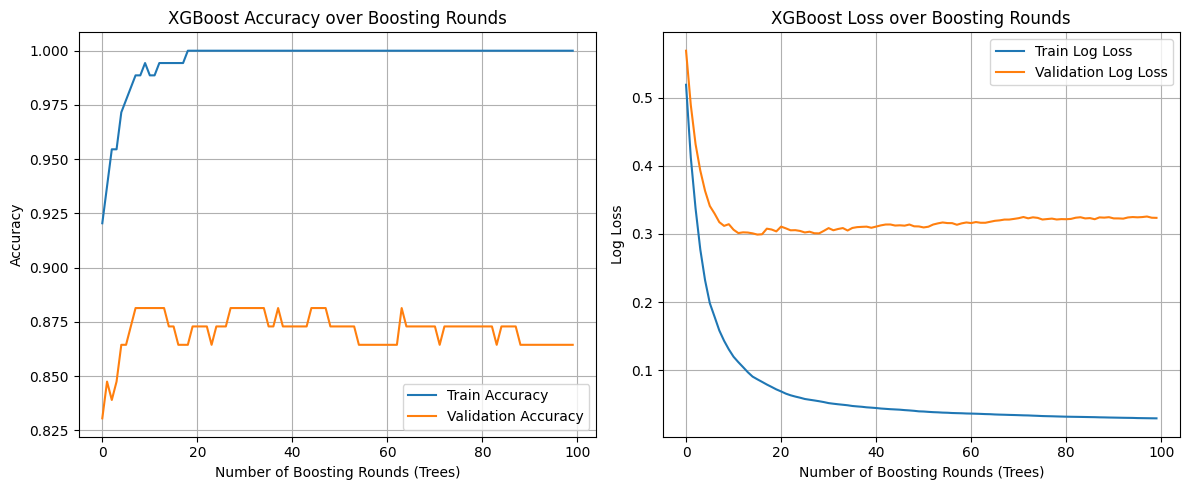

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# --- STEP 1: FORCE RESHAPE DATA BACK TO 2D ---
# Ensure X_train and X_test are 2D for XGBoost: (N_samples, N_features)

# Get the number of samples (rows) and automatically calculate the total number of features.
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

print(f"Final X_train 2D shape: {X_train_2d.shape}")
print(f"Final X_test 2D shape: {X_test_2d.shape}")


# --- STEP 2: TRAIN MODEL AND RECORD HISTORY (with multiple metrics) ---

# Define the evaluation set for monitoring training progress
eval_set = [(X_train_2d, y_train), (X_test_2d, y_test)]

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    # Key Change: Use a list of metrics: 'logloss' and 'error' (which is 1-Accuracy)
    eval_metric=['logloss', 'error'],
    use_label_encoder=False,
    n_estimators=100
)

# Train the model and record history
# Early stopping is often added here to stop training if validation metric doesn't improve
xgb_model.fit(
    X_train_2d,
    y_train,
    eval_set=eval_set,
    verbose=False
)

# --- STEP 3: EXTRACT AND PLOT THE HISTORY ---

results = xgb_model.evals_result()

# Extract Loss (Log Loss)
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

# Extract Error and convert to Accuracy (Accuracy = 1 - Error)
train_acc = 1 - np.array(results['validation_0']['error'])
val_acc = 1 - np.array(results['validation_1']['error'])

epochs = range(len(train_loss))

# Create the plot: Two subplots (Accuracy and Loss)
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('XGBoost Accuracy over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds (Trees)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Log Loss')
plt.plot(epochs, val_loss, label='Validation Log Loss')
plt.title('XGBoost Loss over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds (Trees)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust subplots to fit in figure area
plt.show()

Final X_train 2D shape: (176, 5)
Final X_test 2D shape: (118, 5)


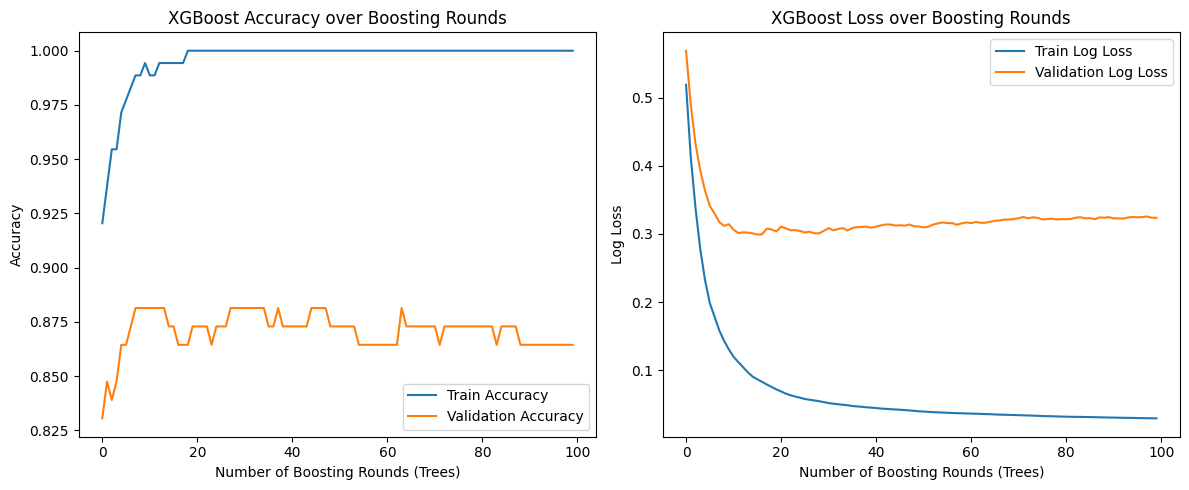

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are already defined and loaded
# If not, you must ensure they exist before running this code.

# --- STEP 1: FORCE RESHAPE DATA BACK TO 2D ---
# Ensure X_train and X_test are 2D for XGBoost: (N_samples, N_features)

# Get the number of samples (rows) and automatically calculate the total number of features.
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

print(f"Final X_train 2D shape: {X_train_2d.shape}")
print(f"Final X_test 2D shape: {X_test_2d.shape}")


# --- STEP 2: TRAIN MODEL AND RECORD HISTORY (with multiple metrics) ---

# Define the evaluation set for monitoring training progress
eval_set = [(X_train_2d, y_train), (X_test_2d, y_test)]

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    # Key Change: Use a list of metrics: 'logloss' and 'error' (which is 1-Accuracy)
    eval_metric=['logloss', 'error'],
    use_label_encoder=False,
    n_estimators=100
)

# Train the model and record history
xgb_model.fit(
    X_train_2d,
    y_train,
    eval_set=eval_set,
    verbose=False
)

# --- STEP 3: EXTRACT AND PLOT THE HISTORY (Grids removed) ---

results = xgb_model.evals_result()

# Extract Loss (Log Loss)
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

# Extract Error and convert to Accuracy (Accuracy = 1 - Error)
train_acc = 1 - np.array(results['validation_0']['error'])
val_acc = 1 - np.array(results['validation_1']['error'])

epochs = range(len(train_loss))

# Create the plot: Two subplots (Accuracy and Loss)
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('XGBoost Accuracy over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds (Trees)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False) # Grid removed

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Log Loss')
plt.plot(epochs, val_loss, label='Validation Log Loss')
plt.title('XGBoost Loss over Boosting Rounds')
plt.xlabel('Number of Boosting Rounds (Trees)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(False) # Grid removed

plt.tight_layout()
plt.show()